In [215]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import loompy
import gseapy
from anndata import AnnData
import matplotlib.pyplot as plt

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()

# In/Out

In [8]:
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/results/"
Data = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/mixl_chim_atlas.h5"
Results = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/data/mixl_chim_atlas_analysis_anna.h5"

gene_conversion = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/gene_id_name_conversion.csv"

In [9]:
sc.settings.set_figure_params(dpi=80)

In [4]:
#adata = sc.read_h5ad("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/data/mixl_chim_atlas.h5")

In [5]:
#adata_wt = sc.read_loom("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/wildtype_injection/chimera-wt/adata_wt.h5")

In [107]:
adata_wt = ad.read_loom('C:/Users/aamw4/home/aamw4/wt_chim_atlas_analysis.h5')

KeyboardInterrupt: 

In [125]:
adata.obs.index

Index(['atlas_cell_1-0', 'atlas_cell_2-0', 'atlas_cell_5-0', 'atlas_cell_6-0',
       'atlas_cell_8-0', 'atlas_cell_9-0', 'atlas_cell_10-0',
       'atlas_cell_11-0', 'atlas_cell_12-0', 'atlas_cell_13-0',
       ...
       'wt_cell_13472-1', 'wt_cell_13473-1', 'wt_cell_13474-1',
       'wt_cell_13475-1', 'wt_cell_13476-1', 'wt_cell_13477-1',
       'wt_cell_13478-1', 'wt_cell_13479-1', 'wt_cell_13480-1',
       'wt_cell_13481-1'],
      dtype='object', length=129793)

In [97]:
np.unique(adata.obs.tdTom)

array(['nan', 'neg', 'pos'], dtype=object)

In [174]:
#subsetting only the chimera cells = won't need atlas cells for now
    
adata_wt = adata[adata.obs_names.str.startswith('wt'),:].copy()

In [126]:
adata_wt.obs.index

Index(['wt_cell_1-1', 'wt_cell_2-1', 'wt_cell_3-1', 'wt_cell_4-1',
       'wt_cell_5-1', 'wt_cell_6-1', 'wt_cell_7-1', 'wt_cell_8-1',
       'wt_cell_9-1', 'wt_cell_10-1',
       ...
       'wt_cell_13472-1', 'wt_cell_13473-1', 'wt_cell_13474-1',
       'wt_cell_13475-1', 'wt_cell_13476-1', 'wt_cell_13477-1',
       'wt_cell_13478-1', 'wt_cell_13479-1', 'wt_cell_13480-1',
       'wt_cell_13481-1'],
      dtype='object', length=13481)

In [175]:
print(adata_wt.shape)
#adata[1:10,1:10]
adata_wt.var_names_make_unique()
adata_wt.obs.index

(13481, 29453)


Index(['wt_cell_1-1', 'wt_cell_2-1', 'wt_cell_3-1', 'wt_cell_4-1',
       'wt_cell_5-1', 'wt_cell_6-1', 'wt_cell_7-1', 'wt_cell_8-1',
       'wt_cell_9-1', 'wt_cell_10-1',
       ...
       'wt_cell_13472-1', 'wt_cell_13473-1', 'wt_cell_13474-1',
       'wt_cell_13475-1', 'wt_cell_13476-1', 'wt_cell_13477-1',
       'wt_cell_13478-1', 'wt_cell_13479-1', 'wt_cell_13480-1',
       'wt_cell_13481-1'],
      dtype='object', length=13481)

In [176]:
#adata_wt WT chimera
string = '-1'
# add gut clusters
wt_tab = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+haem+meso+gut.tab', '\t')
gut_subclust = wt_tab[['cell', 'gut_subclust.mapped']]
gut_subclust.cell = [cell + string for cell in gut_subclust.cell]
gut_subclust.index = gut_subclust.cell
adata_wt.obs = pd.merge(adata_wt.obs, gut_subclust, left_index=True, right_index=True)
#adata.obs = adata.obs.set_index('cell', drop=True)

# add haem clusters
#haem_subclust = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+haem+meso+gut.tab', '\t')
haem_subclust = wt_tab[['cell', 'haem_subclust.mapped']]
haem_subclust.cell = [cell + string for cell in haem_subclust.cell]
haem_subclust.index = haem_subclust.cell
adata_wt.obs = pd.merge(adata_wt.obs, haem_subclust, left_index=True, right_index=True)
#adata.obs = adata.obs.set_index('cell', drop=True)


# add meso clusters
#meso_subclust = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+haem+meso+gut.tab', '\t')
meso_subclust = wt_tab[['cell', 'meso.mapped']]
meso_subclust.cell = [cell + string for cell in meso_subclust.cell]
meso_subclust.index = meso_subclust.cell
adata_wt.obs = pd.merge(adata_wt.obs, meso_subclust, left_index=True, right_index=True)
#adata.obs = adata.obs.set_index('cell', drop=True)

C:\Users\aamw4\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3146: DtypeWarning: Columns (6,7,17,26,30,32,37,39,40,41) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
C:\Users\aamw4\Anaconda3\lib\site-packages\pandas\core\generic.py:5168: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value


In [237]:
np.unique(adata_wt.obs['meso.mapped'])

TypeError: '<' not supported between instances of 'float' and 'str'

In [177]:
adata_wt.obs.index

Index(['wt_cell_1-1', 'wt_cell_2-1', 'wt_cell_3-1', 'wt_cell_4-1',
       'wt_cell_5-1', 'wt_cell_6-1', 'wt_cell_7-1', 'wt_cell_8-1',
       'wt_cell_9-1', 'wt_cell_10-1',
       ...
       'wt_cell_13472-1', 'wt_cell_13473-1', 'wt_cell_13474-1',
       'wt_cell_13475-1', 'wt_cell_13476-1', 'wt_cell_13477-1',
       'wt_cell_13478-1', 'wt_cell_13479-1', 'wt_cell_13480-1',
       'wt_cell_13481-1'],
      dtype='object', length=13481)

In [178]:
adata_wt.var_names #alias for .var.index


Index(['ENSMUSG00000000001', 'ENSMUSG00000000003', 'ENSMUSG00000000028',
       'ENSMUSG00000000031', 'ENSMUSG00000000037', 'ENSMUSG00000000049',
       'ENSMUSG00000000056', 'ENSMUSG00000000058', 'ENSMUSG00000000078',
       'ENSMUSG00000000085',
       ...
       'ENSMUSG00000114168', 'ENSMUSG00000114175', 'ENSMUSG00000114178',
       'ENSMUSG00000114181', 'ENSMUSG00000114185', 'ENSMUSG00000114186',
       'ENSMUSG00000114188', 'ENSMUSG00000114189', 'ENSMUSG00000114192',
       'tomato-td'],
      dtype='object', length=29453)

In [179]:
adata_wt.obs

,barcode,batch,cell_x,celltype,celltype.mapped,closest.cell,cluster,cluster.stage,cluster.sub,cluster.theiler,...,tdTom,theiler,umapX,umapY,cell_y,gut_subclust.mapped,cell_x,haem_subclust.mapped,cell_y,meso.mapped
wt_cell_1-1,AAACCTGAGACCTTTG,1,nan,Haematoendothelial progenitors,Haematoendothelial progenitors,atlas_cell_52006,NaN,NaN,NaN,NaN,...,pos,nan,NaN,NaN,wt_cell_1-1,NaN,wt_cell_1-1,Haem2,wt_cell_1-1,NaN
wt_cell_2-1,AAACCTGAGCGCCTCA,1,nan,Mesenchyme,Mesenchyme,atlas_cell_33502,NaN,NaN,NaN,NaN,...,pos,nan,NaN,NaN,wt_cell_2-1,NaN,wt_cell_2-1,NaN,wt_cell_2-1,NaN
wt_cell_3-1,AAACCTGAGGATCGCA,1,nan,Primitive Streak,Primitive Streak,atlas_cell_112755,NaN,NaN,NaN,NaN,...,pos,nan,NaN,NaN,wt_cell_3-1,NaN,wt_cell_3-1,NaN,wt_cell_3-1,NaN
wt_cell_4-1,AAACCTGCACGTAAGG,1,nan,NMP,NMP,atlas_cell_68127,NaN,NaN,NaN,NaN,...,pos,nan,NaN,NaN,wt_cell_4-1,NaN,wt_cell_4-1,NaN,wt_cell_4-1,NaN
wt_cell_5-1,AAACCTGCAGACAGGT,1,nan,Caudal Mesoderm,Caudal Mesoderm,atlas_cell_68596,NaN,NaN,NaN,NaN,...,pos,nan,NaN,NaN,wt_cell_5-1,NaN,wt_cell_5-1,NaN,wt_cell_5-1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
wt_cell_13477-1,TTTGGTTGTGATGCCC,1,nan,Rostral neurectoderm,Rostral neurectoderm,atlas_cell_8750,NaN,NaN,NaN,NaN,...,neg,nan,NaN,NaN,wt_cell_13477-1,NaN,wt_cell_13477-1,NaN,wt_cell_13477-1,NaN
wt_cell_13478-1,TTTGGTTTCGCTTAGA,1,nan,Erythroid3,Erythroid3,atlas_cell_97649,NaN,NaN,NaN,NaN,...,neg,nan,NaN,NaN,wt_cell_13478-1,NaN,wt_cell_13478-1,Ery4,wt_cell_13478-1,NaN
wt_cell_13479-1,TTTGTCAAGACAATAC,1,nan,Erythroid3,Erythroid3,atlas_cell_38655,NaN,NaN,NaN,NaN,...,neg,nan,NaN,NaN,wt_cell_13479-1,NaN,wt_cell_13479-1,Ery3,wt_cell_13479-1,NaN
wt_cell_13480-1,TTTGTCAAGGTAGCTG,1,nan,Erythroid2,Erythroid2,atlas_cell_133630,NaN,NaN,NaN,NaN,...,neg,nan,NaN,NaN,wt_cell_13480-1,NaN,wt_cell_13480-1,Ery2,wt_cell_13480-1,NaN


# trying to convert ensemble_ID to gene_ID

In [180]:
#df = pd.read_csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/data/ensembl_gene_table_81.txt", delim_whitespace=True, header=None, skiprows=1, names=['Ensembl Gene ID','Associated Gene Name','Gene type']) #without naming header, didn't work
#df.columns
df = pd.read_csv('C:/Users/aamw4/home/aamw4/ensembl_gene_table_81.txt', header=0, sep='\t', index_col=0)
df

,Associated Gene Name,Gene type
Ensembl Gene ID,,
ENSMUSG00000064372,mt-Tp,Mt_tRNA
ENSMUSG00000064371,mt-Tt,Mt_tRNA
ENSMUSG00000064370,mt-Cytb,protein_coding
ENSMUSG00000064369,mt-Te,Mt_tRNA
ENSMUSG00000064368,mt-Nd6,protein_coding
...,...,...
ENSMUSG00000097611,RP24-152F23.3,protein_coding
ENSMUSG00000107101,RP23-465P18.1,antisense
ENSMUSG00000097395,RP24-152F23.5,protein_coding


In [181]:
list_names = [name for name in list(df.index) if name in adata_wt.var_names]

In [182]:
adata_wt =  adata_wt[:,list_names].copy()

In [183]:
adata_wt.var_names = list(df.loc[list_names]['Associated Gene Name'])

In [184]:
adata_wt.var_names_make_unique()

In [185]:
adata_wt.var_names

Index(['mt-Cytb', 'mt-Nd6', 'mt-Nd5', 'mt-Nd4', 'mt-Nd4l', 'mt-Nd3', 'mt-Co3',
       'mt-Atp6', 'mt-Atp8', 'mt-Co2',
       ...
       'Impact', 'Dsg3', 'Fam13b', 'Rprd1a', 'Taf4b', 'Zfp521', 'Hrh4', 'Dsc1',
       'Psma8', '2700062C07Rik'],
      dtype='object', length=27151)

# Subsetting adata to keep only erythrocytes 1 to test WT vs KO

In [20]:
print(adata.obs['celltype.mapped'].cat.categories) #identify names of celltypes in category
adata_ery1 = adata[adata.obs['celltype.mapped'] == 'Erythroid1',:].copy() #subsetting for test
adata_ery1.var_names

Index(['Allantois', 'Anterior Primitive Streak', 'Blood progenitors 1',
       'Blood progenitors 2', 'Cardiomyocytes', 'Caudal Mesoderm',
       'Caudal epiblast', 'Caudal neurectoderm', 'Def. endoderm',
       'Endothelium', 'Erythroid1', 'Erythroid2', 'Erythroid3', 'ExE ectoderm',
       'ExE endoderm', 'ExE mesoderm', 'Forebrain/Midbrain/Hindbrain', 'Gut',
       'Haematoendothelial progenitors', 'Intermediate mesoderm', 'Mesenchyme',
       'Mixed mesoderm', 'NMP', 'Neural crest', 'Notochord', 'PGC',
       'Paraxial mesoderm', 'Parietal endoderm', 'Pharyngeal mesoderm',
       'Rostral neurectoderm', 'Somitic mesoderm', 'Spinal cord',
       'Surface ectoderm', 'Visceral endoderm'],
      dtype='object')


Index(['mt-Cytb', 'mt-Nd6', 'mt-Nd5', 'mt-Nd4', 'mt-Nd4l', 'mt-Nd3', 'mt-Co3',
       'mt-Atp6', 'mt-Atp8', 'mt-Co2',
       ...
       'Impact', 'Dsg3', 'Fam13b', 'Rprd1a', 'Taf4b', 'Zfp521', 'Hrh4', 'Dsc1',
       'Psma8', '2700062C07Rik'],
      dtype='object', length=27917)

# t-test DE subset erythroid 1

ranking genes


... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


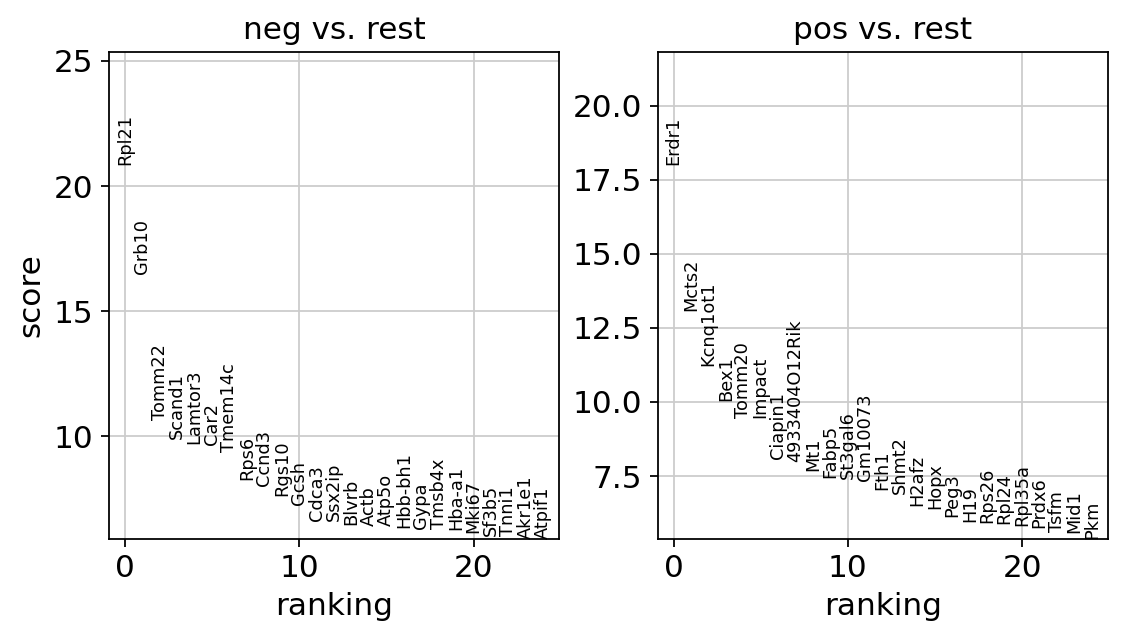

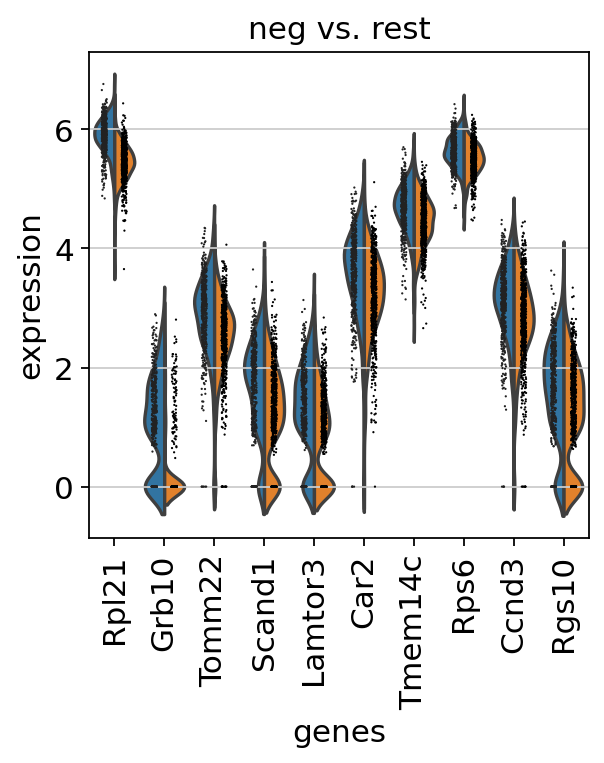

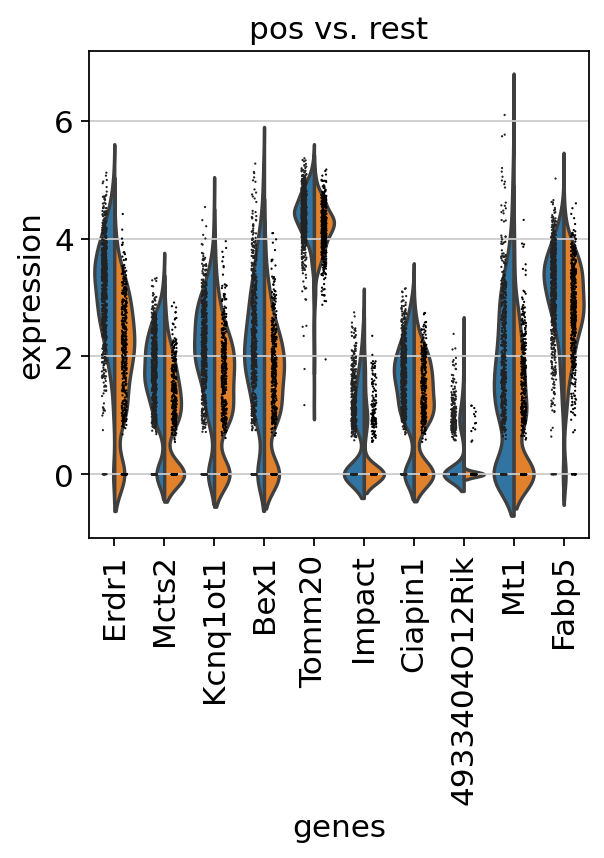

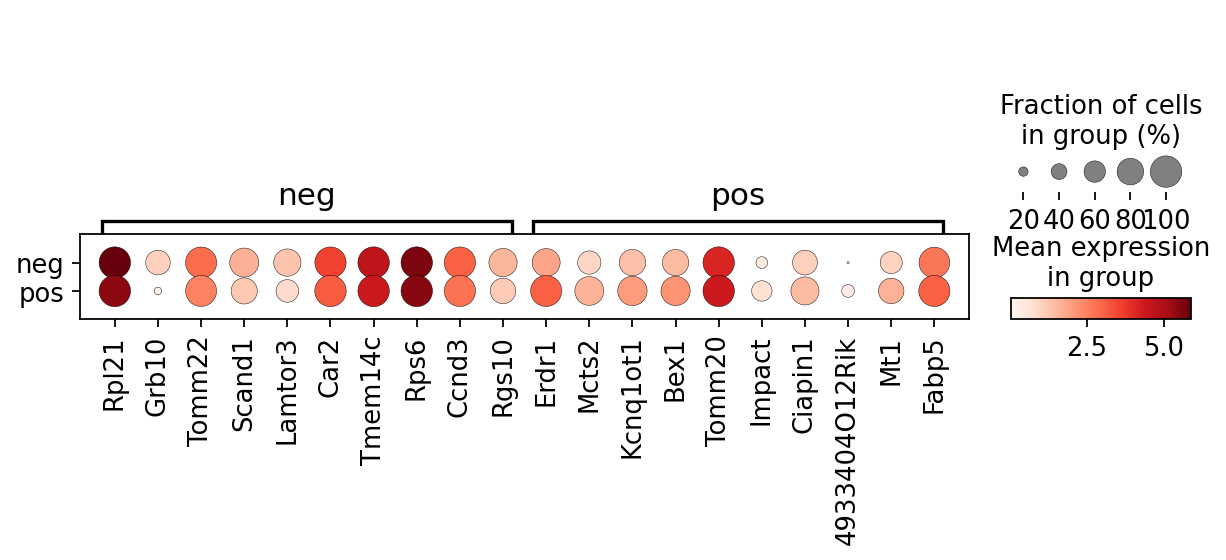

In [21]:
sc.tl.rank_genes_groups(adata_ery1, groupby = 'tdTom', groups = ['neg', 'pos'] ,method='wilcoxon',n_genes=5000, key='wilcoxon') #why neg vs rest and not neg vs pos?
sc.pl.rank_genes_groups(adata_ery1, n_genes=25, sharey=False) #visualisation
sc.pl.rank_genes_groups_violin(adata_ery1, n_genes=10) #visualisation
sc.pl.rank_genes_groups_dotplot(adata_ery1, n_genes=10) #visualisation

In [22]:
adata_ery1.write(Results)

In [23]:
pd.DataFrame(adata_ery1.uns['rank_genes_groups']['names']).head(15)

,neg,pos
0,Rpl21,Erdr1
1,Grb10,Mcts2
2,Tomm22,Kcnq1ot1
3,Scand1,Bex1
4,Lamtor3,Tomm20
5,Car2,Impact
6,Tmem14c,Ciapin1
7,Rps6,4933404O12Rik
8,Ccnd3,Mt1
9,Rgs10,Fabp5


ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


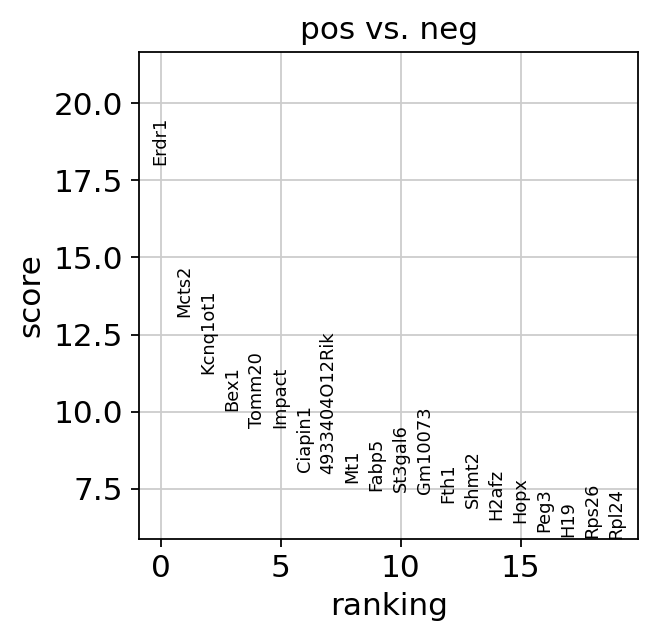

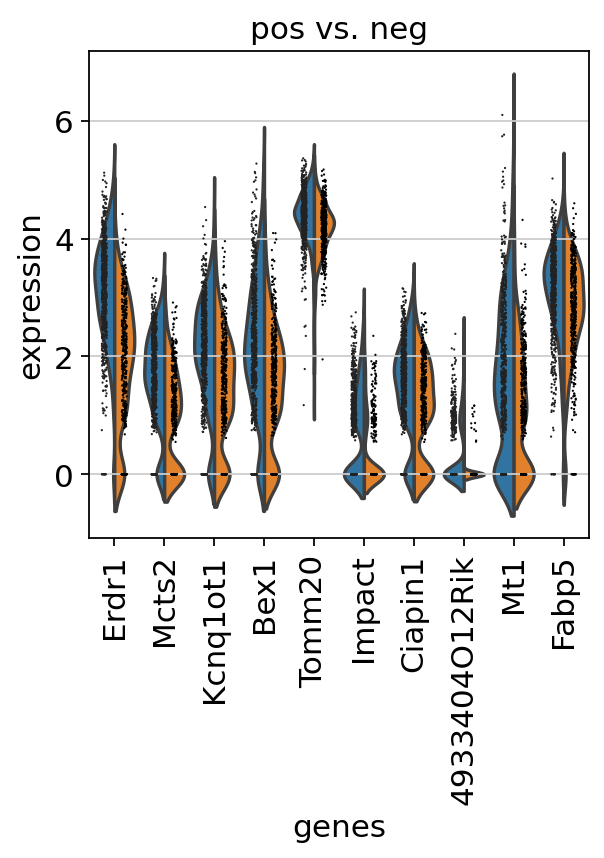

In [24]:
sc.tl.rank_genes_groups(adata_ery1, groupby = 'tdTom', groups=['pos'], reference='neg', method='wilcoxon')
sc.pl.rank_genes_groups(adata_ery1, groupby = 'tdTom', groups=['pos'], n_genes=20)
sc.pl.rank_genes_groups_violin(adata_ery1, groups=['pos'], n_genes=10)


ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


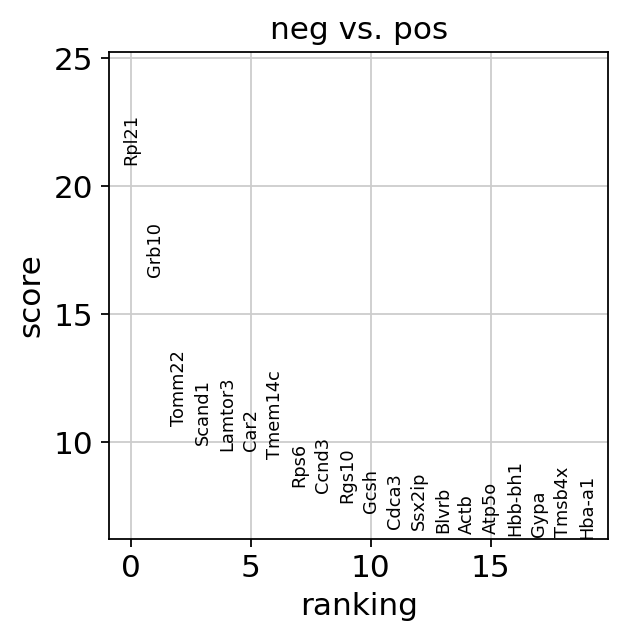

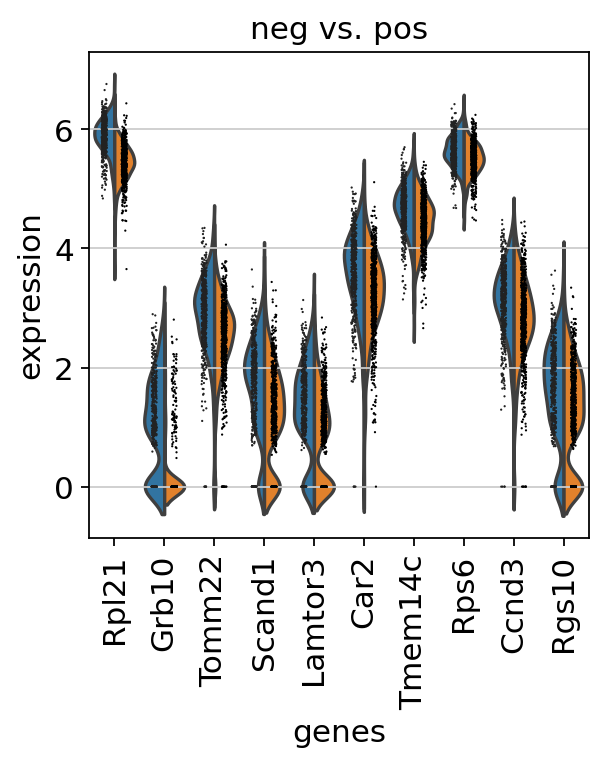

In [25]:
sc.tl.rank_genes_groups(adata_ery1, groupby = 'tdTom', groups=['neg'], reference='pos', method='wilcoxon')
sc.pl.rank_genes_groups(adata_ery1, groupby = 'tdTom', groups=['neg'], n_genes=20)
sc.pl.rank_genes_groups_violin(adata_ery1, groups=['neg'], n_genes=10)

In [26]:
#marker_genes = ['Erdr1', 'Mcts2', 'Kcnq1ot1', 'Bex1', 'Impact', 'Ciaplin1', 'Mt1']


# subsetting for celltype.mapped with more than 50 cells per condition

In [146]:
df = pd.crosstab(adata_wt.obs['celltype.mapped'], adata_wt.obs['tdTom'])
vec = np.array((df.neg>=50) & (df.pos>=50))
print(vec)
df_good = df.loc[vec] #df.iloc[vec] does not work for one reason I don't understand, but df.loc[voc] takes away index
print(df_good)
print(df_good.dtypes)

[False False  True  True False  True False False False False False  True
  True  True False False  True  True  True  True  True  True False  True
  True False False False  True False  True False  True  True  True  True
 False]
tdTom                           neg  pos
celltype.mapped                         
Blood progenitors 1              95   87
Blood progenitors 2             251  266
Caudal Mesoderm                  87  169
Erythroid1                       53   92
Erythroid2                       53  103
Erythroid3                      146  190
ExE mesoderm                    198  489
Forebrain/Midbrain/Hindbrain    430  691
Gut                             196  249
Haematoendothelial progenitors  178  290
Intermediate mesoderm           204  396
Mesenchyme                      361  858
NMP                             265  515
Nascent mesoderm                117  149
Paraxial mesoderm               273  580
Pharyngeal mesoderm             150  397
Rostral neurectoderm            486

# DE by Wilcoxon ranking

In [147]:
def create_tuple_for_for_columns(df_a, multi_level_col):
    """
    Create a columns tuple that can be pandas MultiIndex to create multi level column

    :param df_a: pandas dataframe containing the columns that must form the first level of the multi index
    :param multi_level_col: name of second level column
    :return: tuple containing (second_level_col, firs_level_cols)
    """
    temp_columns = []
    for item in df_a.columns:
        temp_columns.append((multi_level_col, item))
    return temp_columns

In [148]:
sc.settings.figdir = 'C:/Users/aamw4/home/aamw4/plots/heatmaps/'
ran = range(0,525)
df_dea = pd.DataFrame().reindex(ran) #initialization of df_dea #ValueError: Cannot set a frame with no defined index and a value that cannot be converted to a Series
df_dea.dropna(inplace=True)
number_genes = []


for pop in list(df_good.index):
    print(pop)
    adata_rid = adata_wt[adata_wt.obs['celltype.mapped'] == pop,:].copy()
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', n_genes=10000, key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
    df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])

    
    vec_up = np.where((df3['pos']>=np.log2(1.5)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
    vec_down = np.where((df3['neg']>= np.log2(1.5)) & (df2['neg']<= 0.1) )[0]
    
        
    df_pos = pd.DataFrame(df2.loc[vec_up]['pos'])
    df_pos.index = list(df1.loc[vec_up]['pos'])
    df_pos['lfc'] = list(df3.loc[vec_up]['pos'])
    df_pos = df_pos.sort_values(by='lfc',ascending=False)

 
    df_neg = pd.DataFrame(df2.loc[vec_down]['neg'])
    df_neg.index = list(df1.loc[vec_down]['neg'])
    df_neg['lfc'] = list(df3.loc[vec_down]['neg'])
    df_neg = df_neg.sort_values(by='lfc',ascending=False)

 
    lista_n = df_neg.index
    lista_p = df_pos.index
 
    print(len(lista_p))
    print(len(lista_n))
    
    number_pos = len(lista_p)
    number_neg = len(lista_n)
    
    number_genes.append(number_pos)
    number_genes.append(number_neg)
    
    #make a list with lengths of all lists, sort and take maximum
    
    list_pos = lista_p.tolist() #format to list to add to dataframe
    list_neg = lista_n.tolist()
    
    ##create df_dea with gene names, pvaladj and lfc
           
    df_dea[pop + '_pos_g'] = pd.Series(list_pos) #to avoid errors from different lengths, convert to Series
    df_dea[pop + '_pos_pvaladj'] = pd.Series(list(df_pos['pos']))
    df_dea[pop + '_pos_lfc'] = pd.Series(list(df_pos['lfc']))
    
    
    df_dea[pop + '_neg_g'] = pd.Series(list_neg)
    df_dea[pop + '_neg_pvaladj'] = pd.Series(list(df_neg['neg']))
    df_dea[pop + '_neg_lfc'] = pd.Series(list(df_neg['lfc']))
    
        
print('finished ranking genes')
number_genes.sort(reverse=True)
number_genes[0] #prints highest number of selected genes for any celltype population to adapt range accordingly of df-Dea in initialisation

ranking genes
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped_x' as categorical
... storing 'gut_subclust.mapped_y' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


Blood progenitors 1


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
ranking genes
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped_x' as categorical
... storing 'gut_subclust.mapped_y' as categori

6
9
Blood progenitors 2


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)
ranking genes
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped_x' as categorical
... storing 'gut_subclust.mapped_y' as categori

...

    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
ranking genes
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped_x' as categorical
... storing 'gut_subclust.mapped_y' as categori

103
85
Surface ectoderm


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


19
62
finished ranking genes


525

In [149]:
df_dea.to_csv('C:/Users/aamw4/home/aamw4/wt_chim_DEGs_df_dea')

In [150]:
adata_rid.uns["rank_genes_groups"]["names"]

rec.array([('Erdr1', 'Phlda2'), ('Mid1', 'Cdkn1c'), ('mt-Co1', 'Spink1'),
           ..., ('Gm28948', 'Abcb5'), ('Gm3669', 'Fabp4'),
           ('1700034E13Rik', 'Kcnd2')],
          dtype=[('pos', 'O'), ('neg', 'O')])

ranking genes
... storing 'batch' as categorical
... storing 'cell' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical


Blood progenitors 1


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


7
9


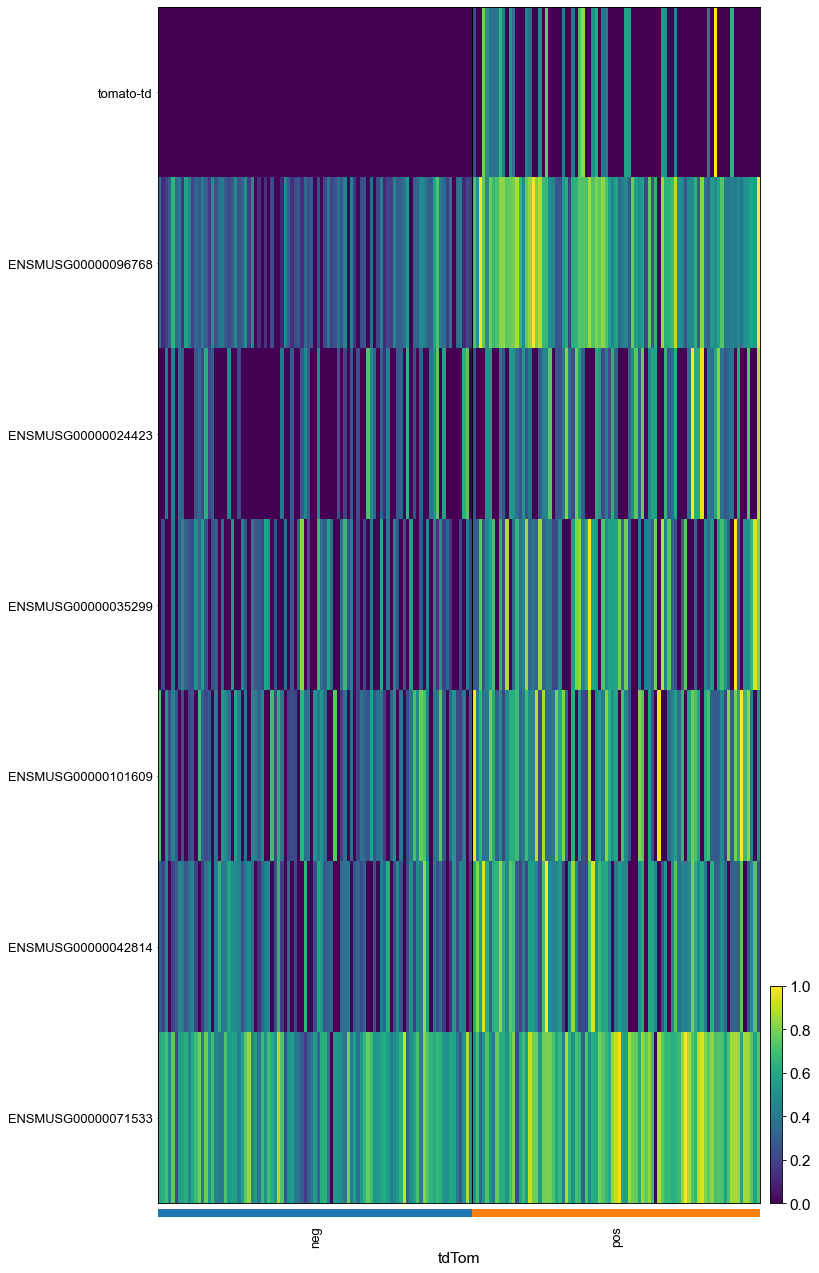

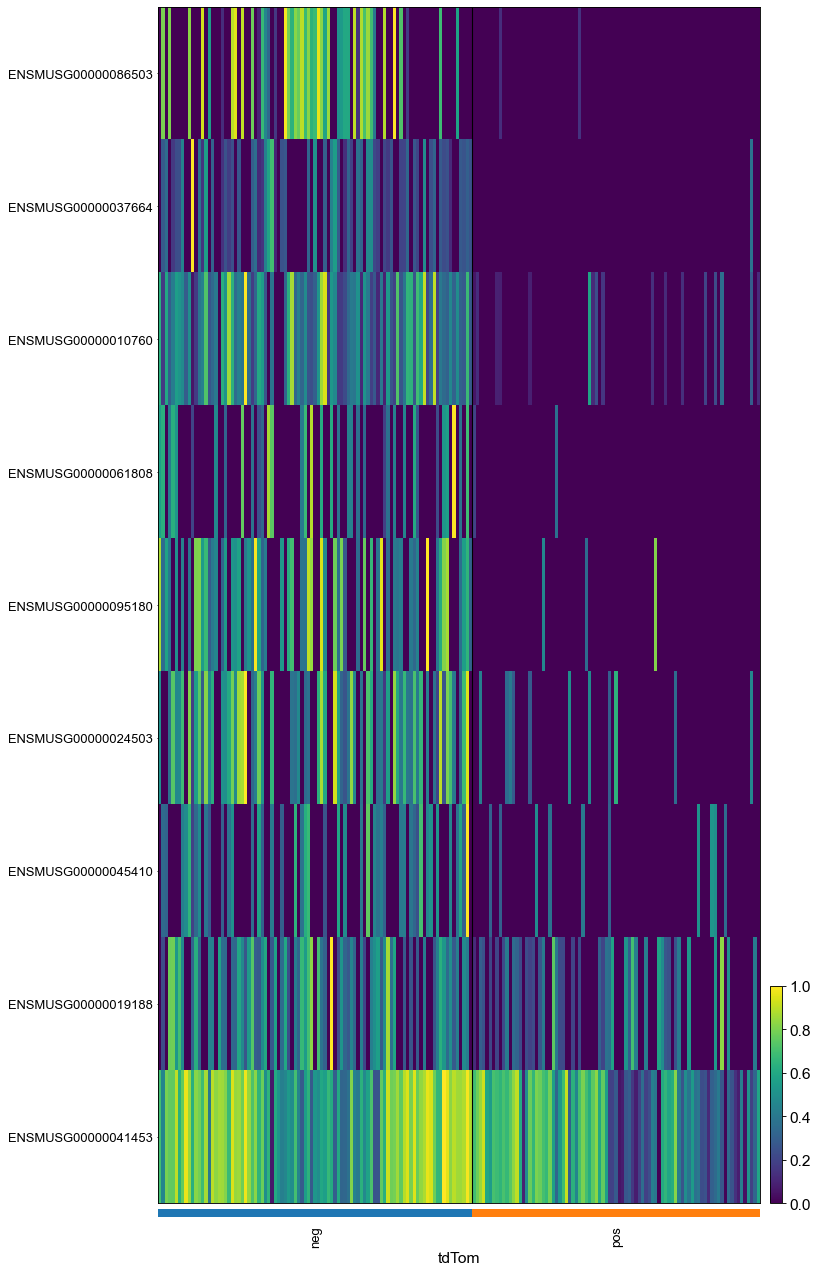

ranking genes
... storing 'batch' as categorical
... storing 'cell' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical


Blood progenitors 2


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


28
48


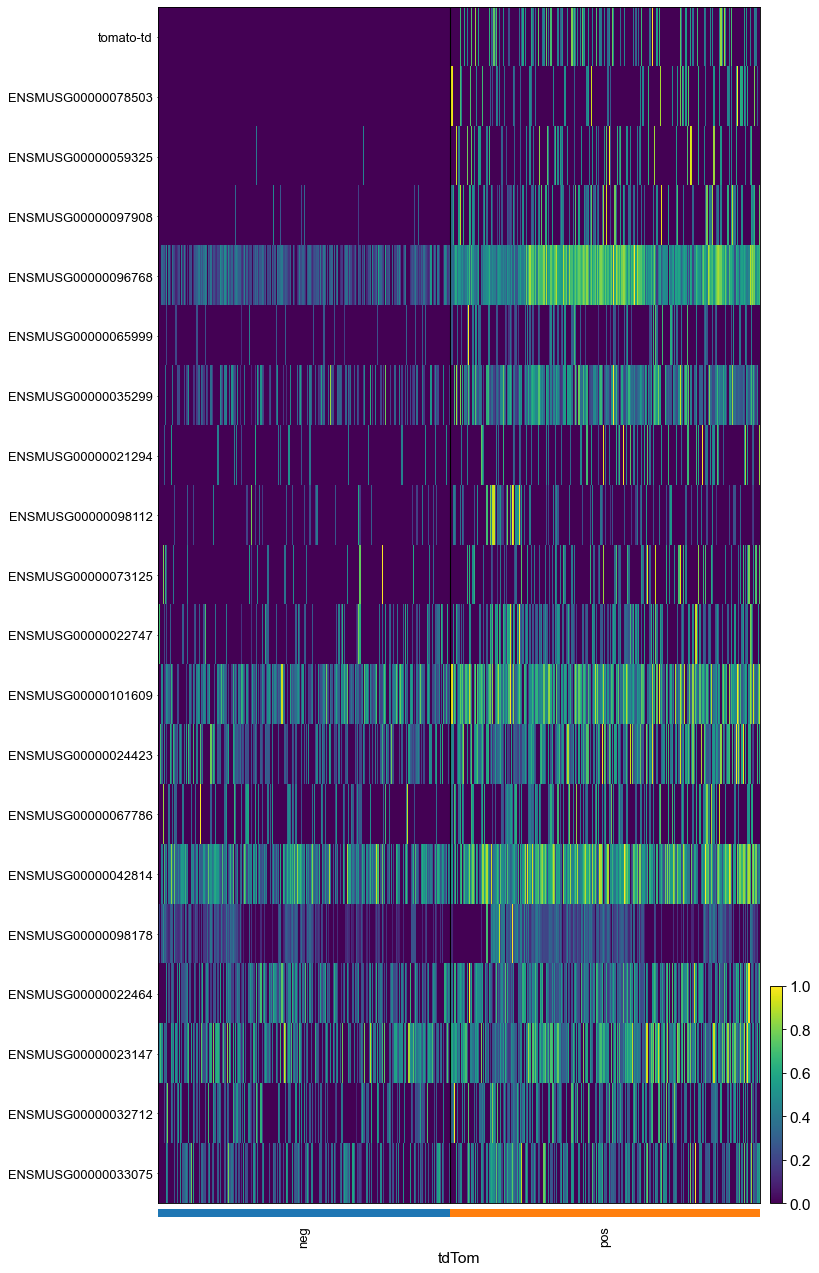

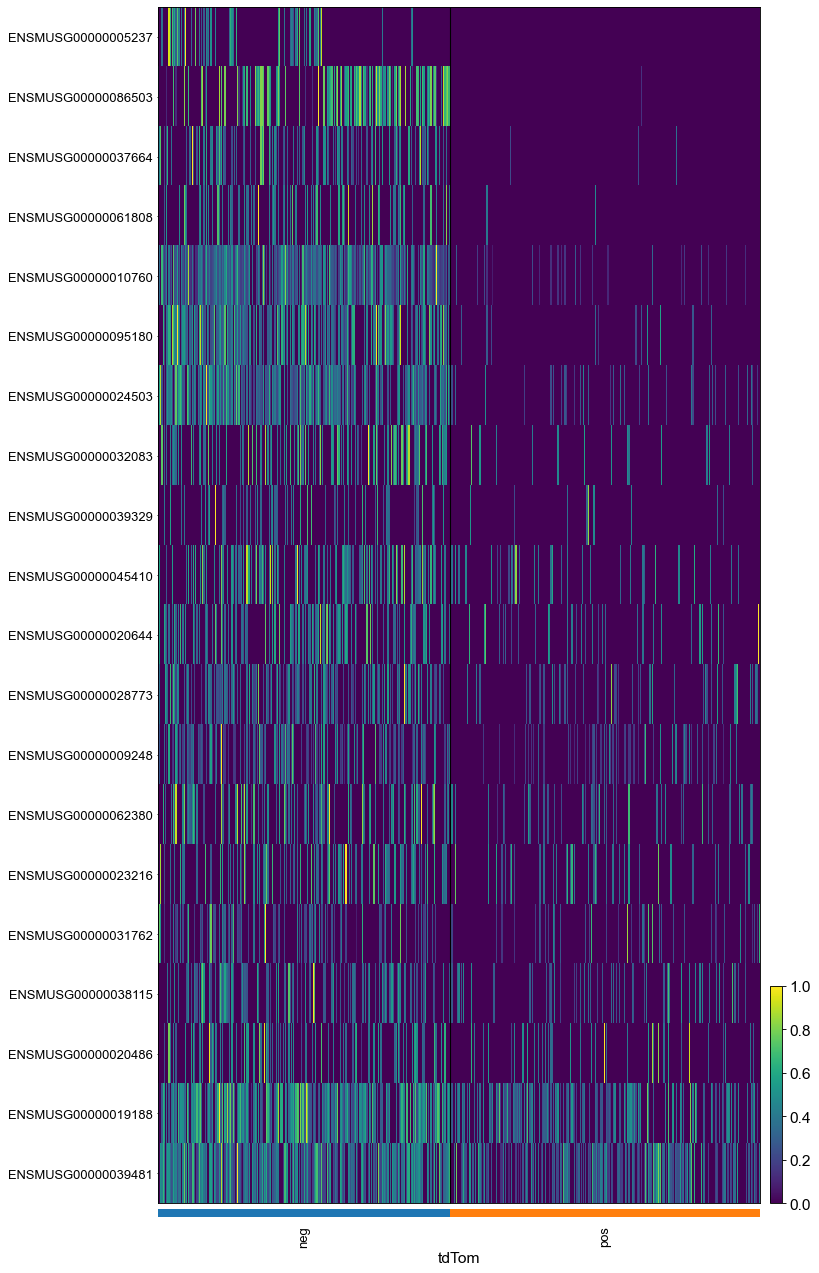

ranking genes
... storing 'batch' as categorical
... storing 'cell' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical


Caudal Mesoderm


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


6
14


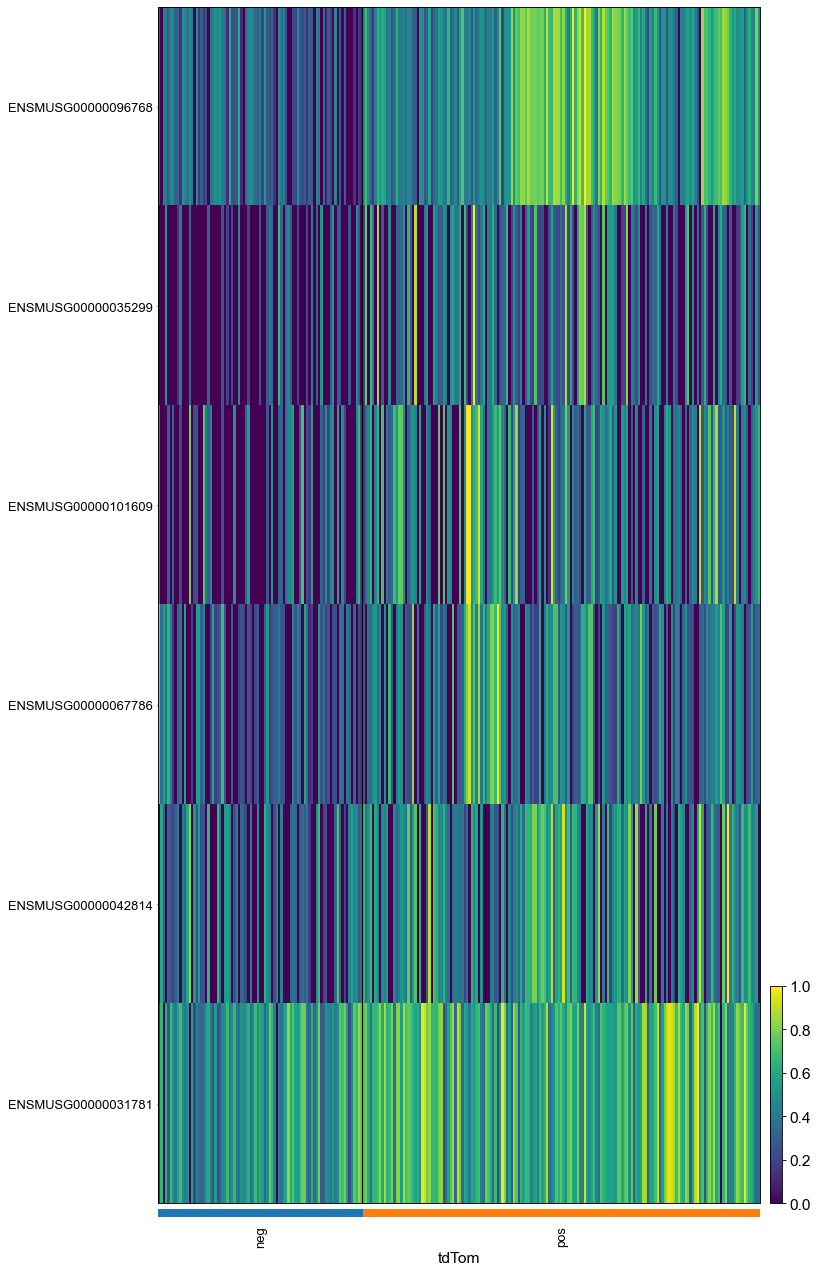

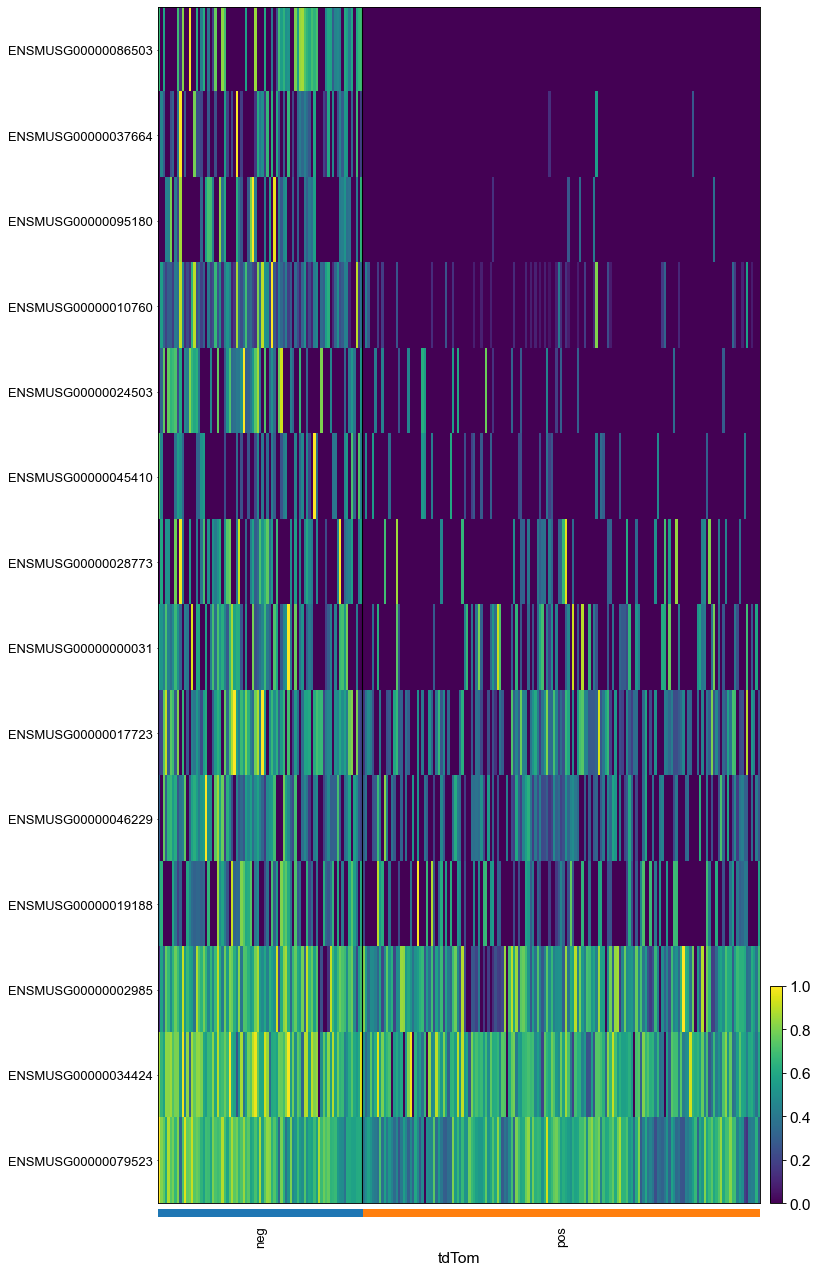

ranking genes
... storing 'batch' as categorical
... storing 'cell' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical


Erythroid1


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


262
119


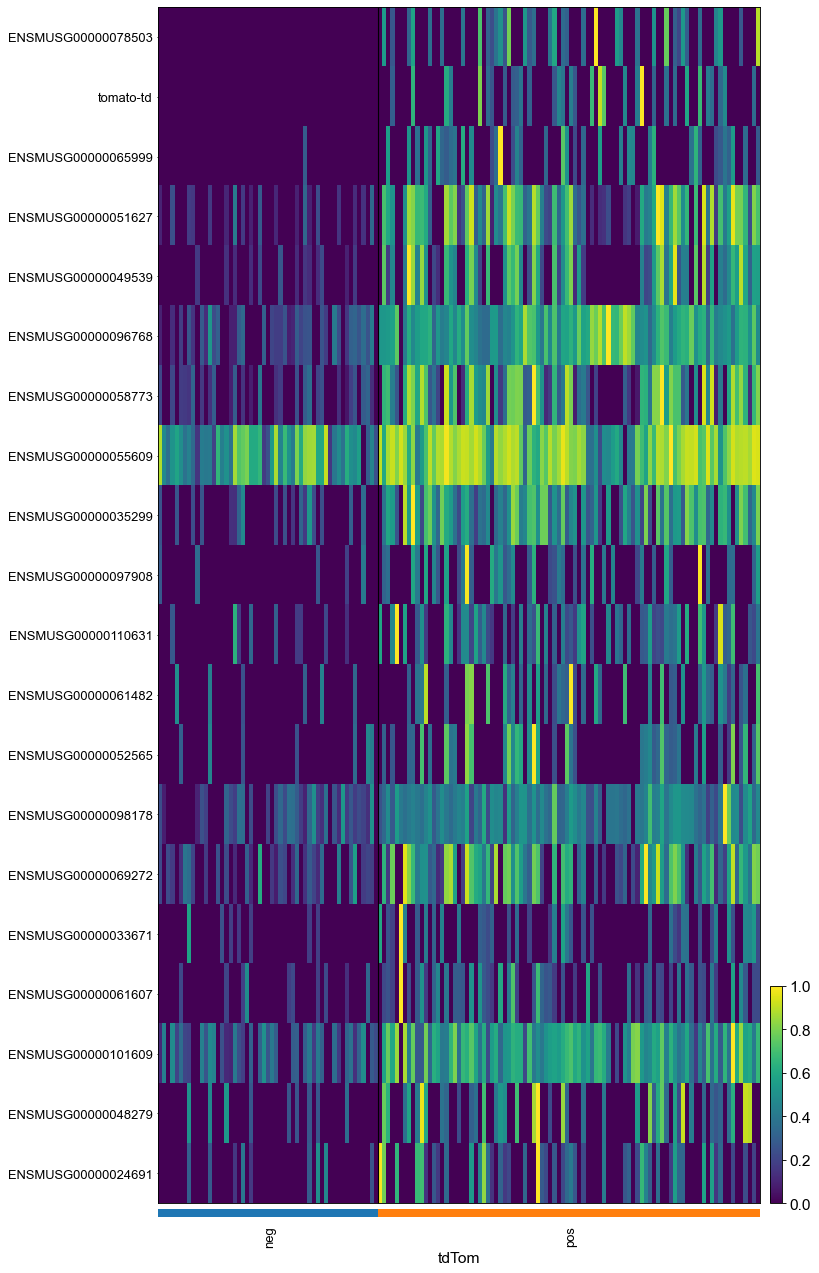

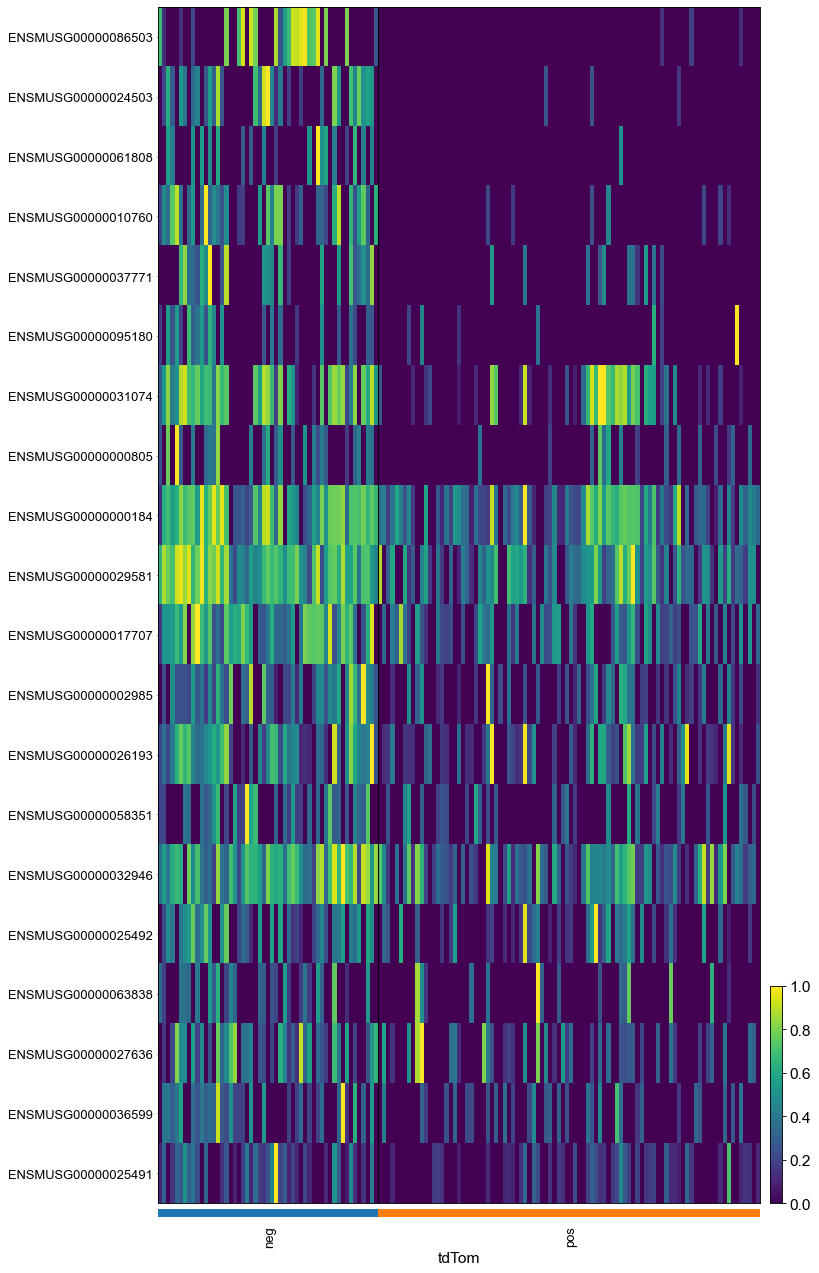

ranking genes
... storing 'batch' as categorical
... storing 'cell' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical


Erythroid2


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


317
179


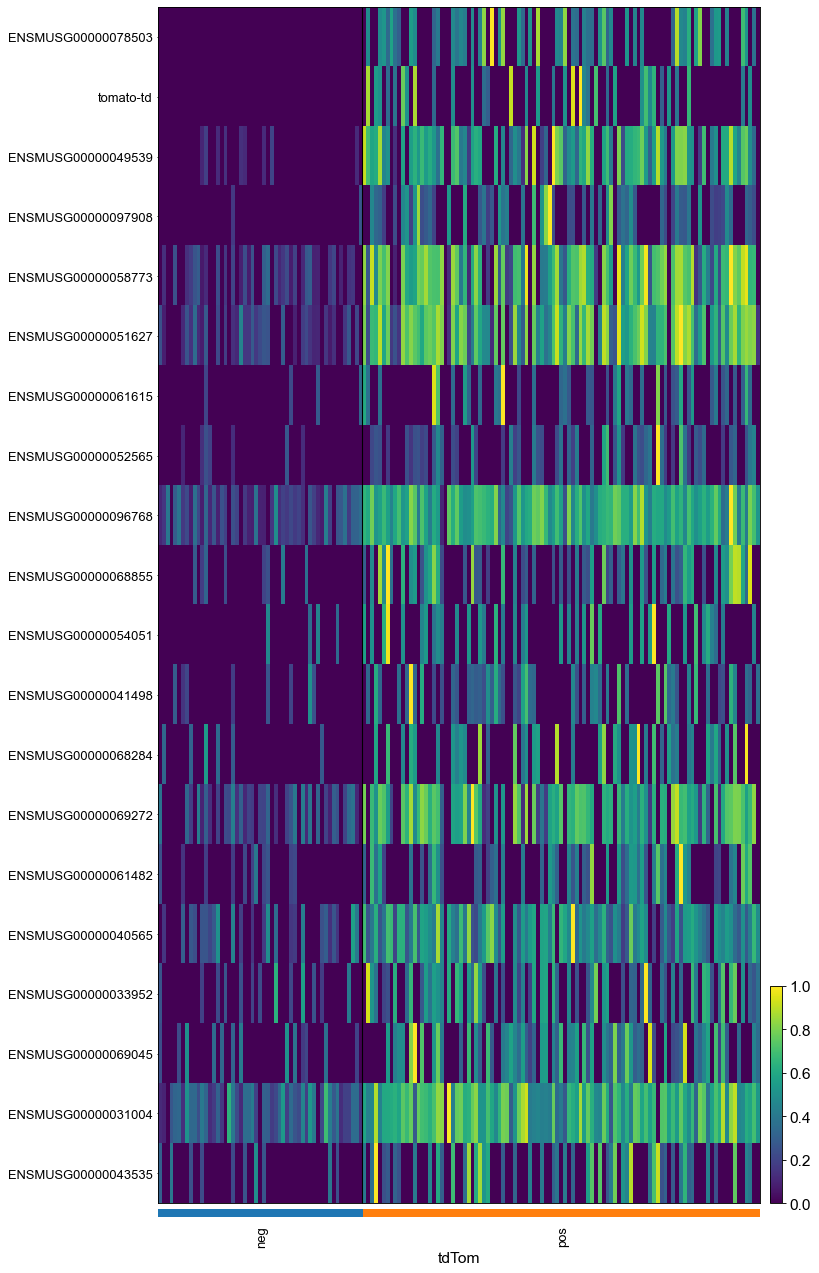

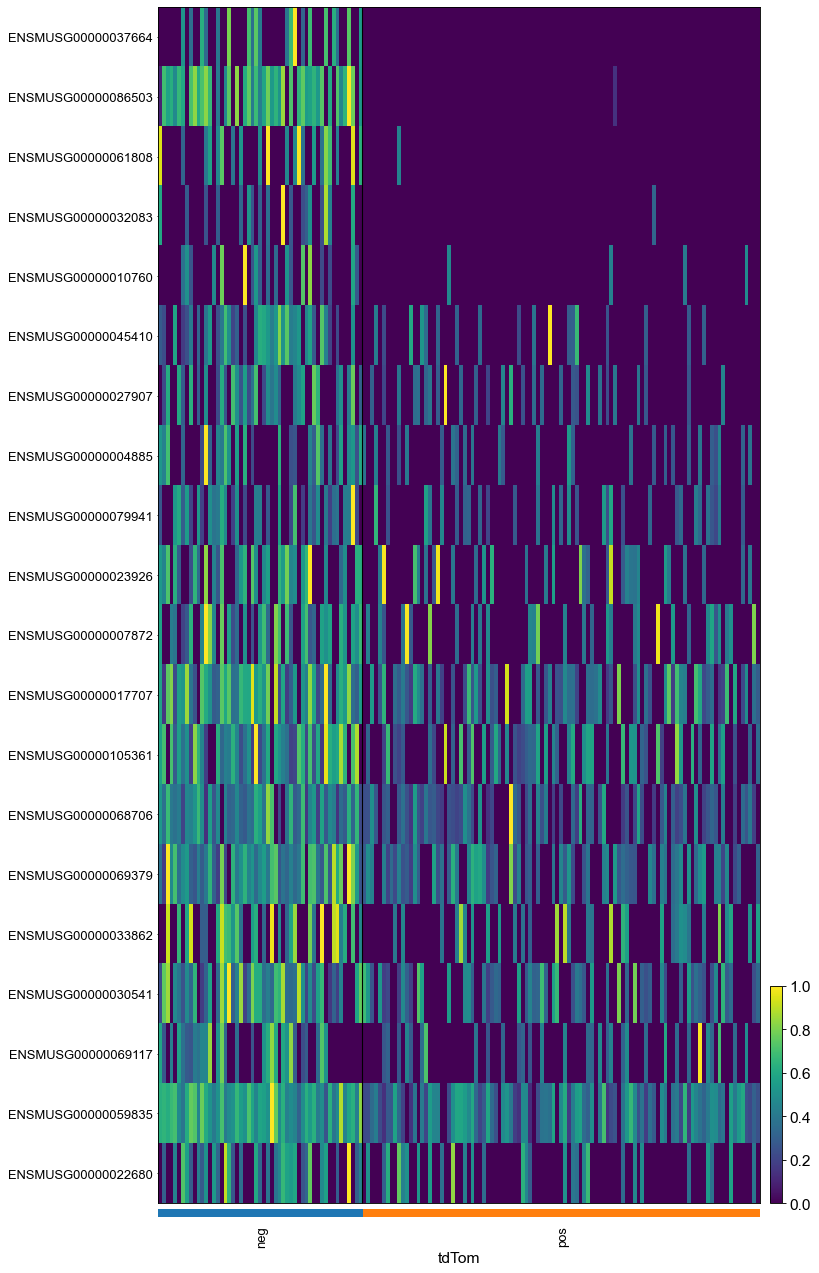

ranking genes
... storing 'batch' as categorical
... storing 'cell' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical


Erythroid3


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


525
315


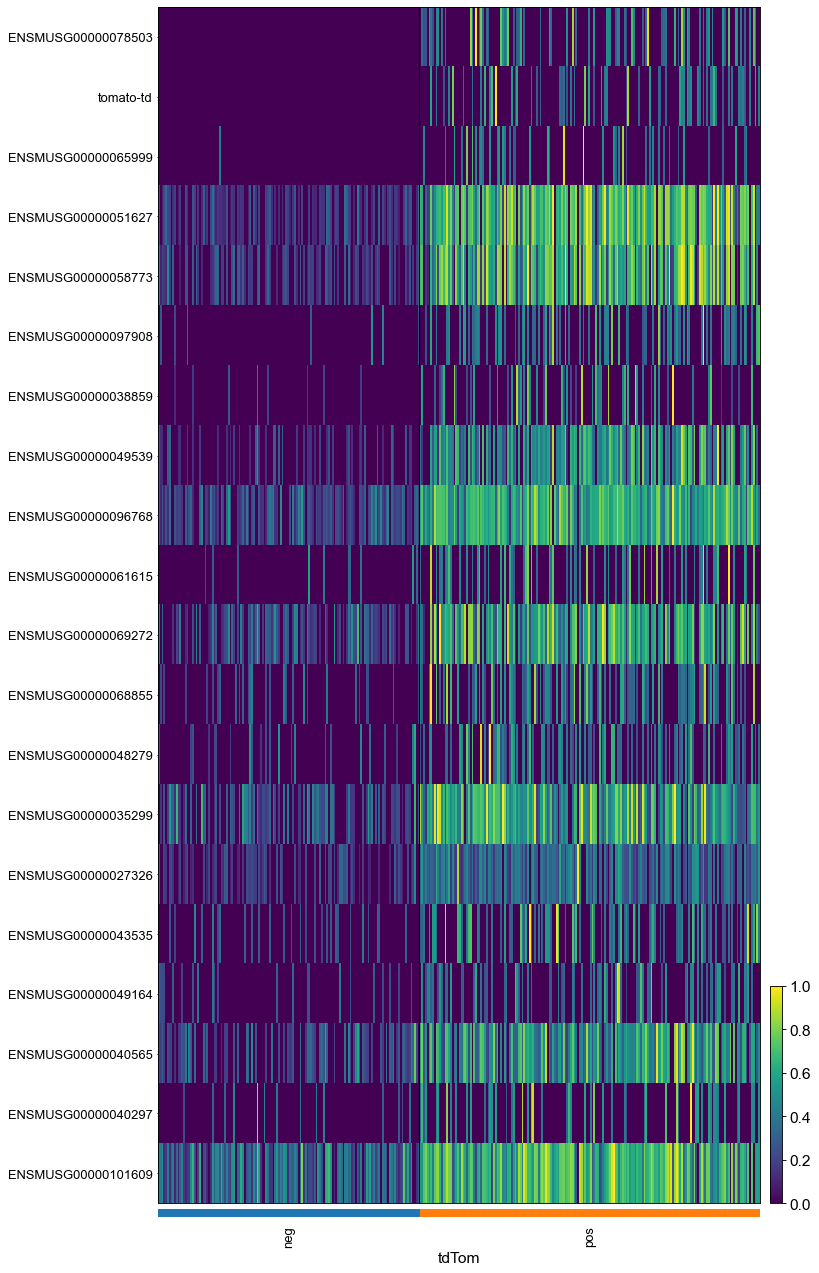

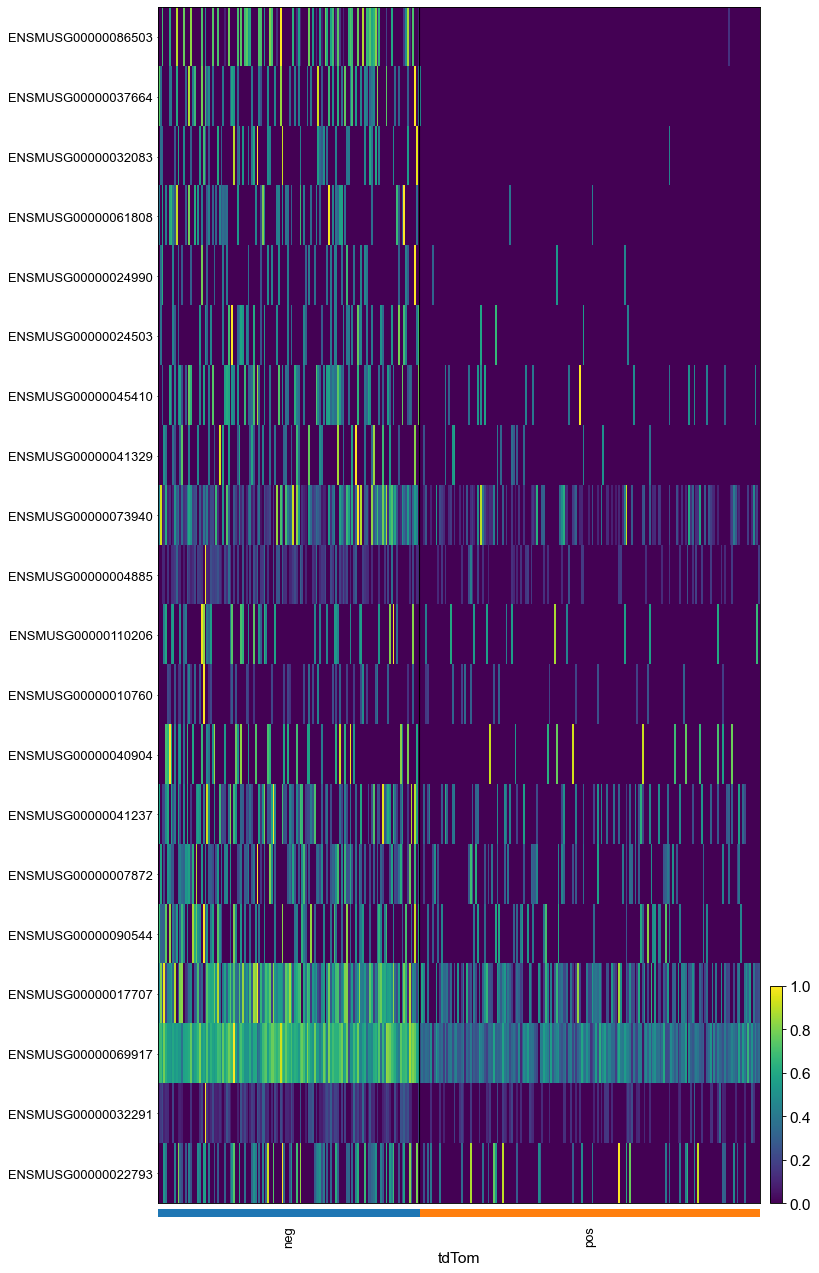

ranking genes
... storing 'barcode' as categorical
... storing 'batch' as categorical
... storing 'cell' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical


ExE mesoderm


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


68
66


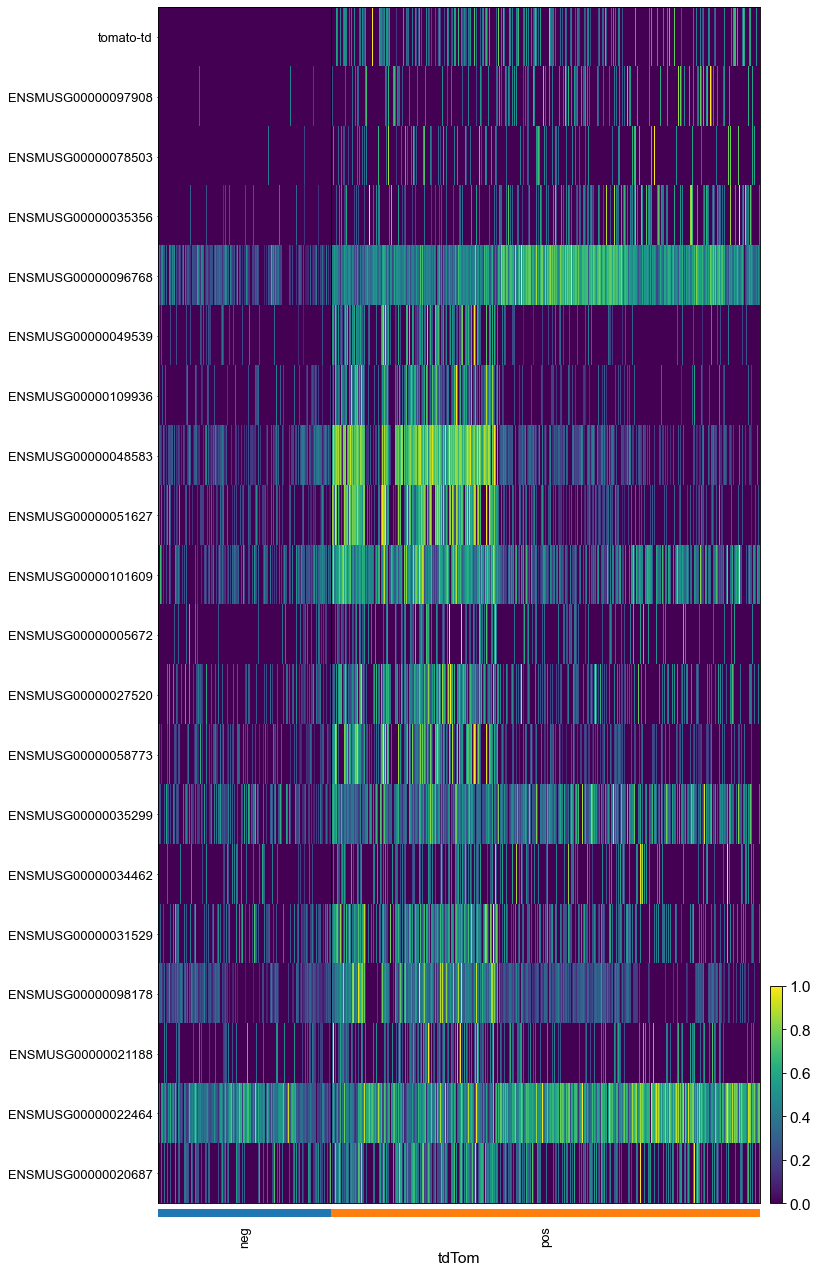

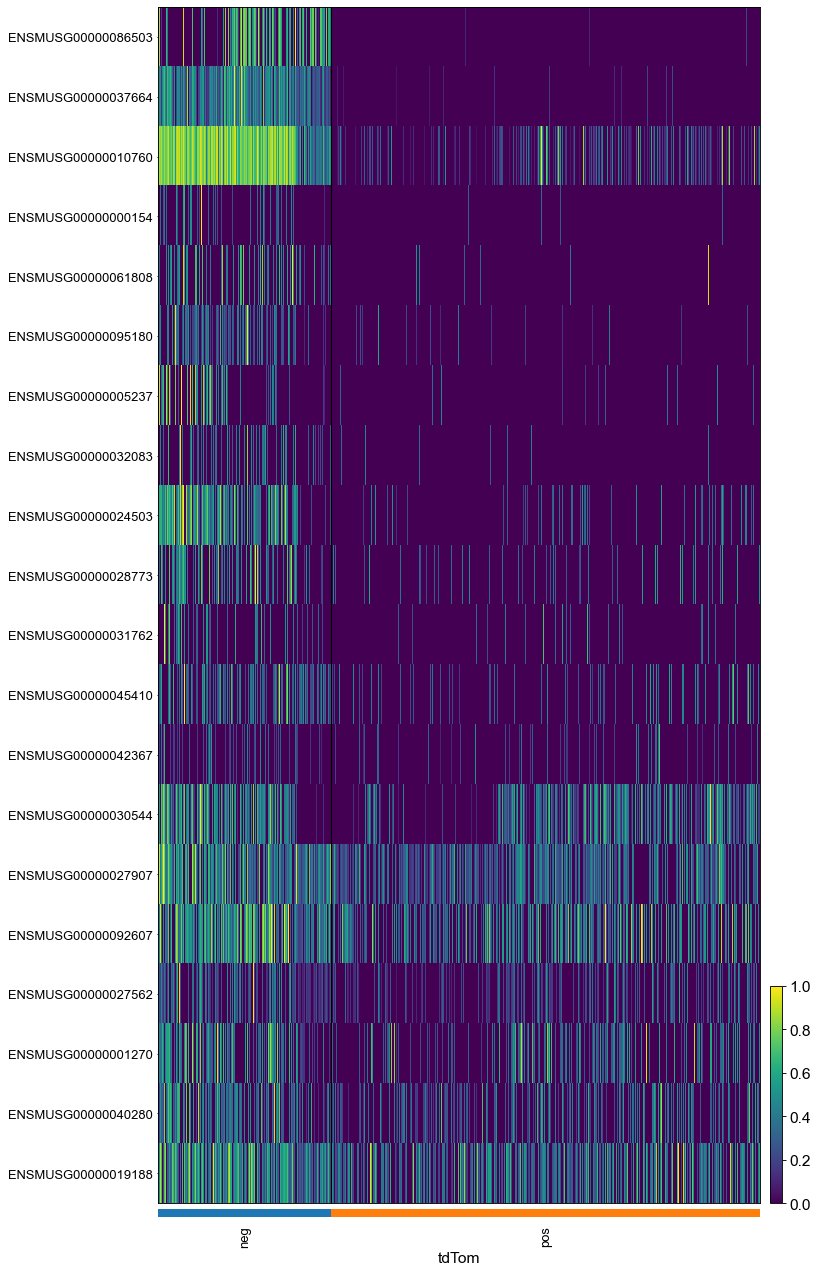

ranking genes
... storing 'batch' as categorical
... storing 'cell' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical


Forebrain/Midbrain/Hindbrain


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


151
80


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\aamw4\\home\\aamw4\\plots\\heatmaps\\heatmapForebrain\\Midbrain\\Hindbrain_pos.png'

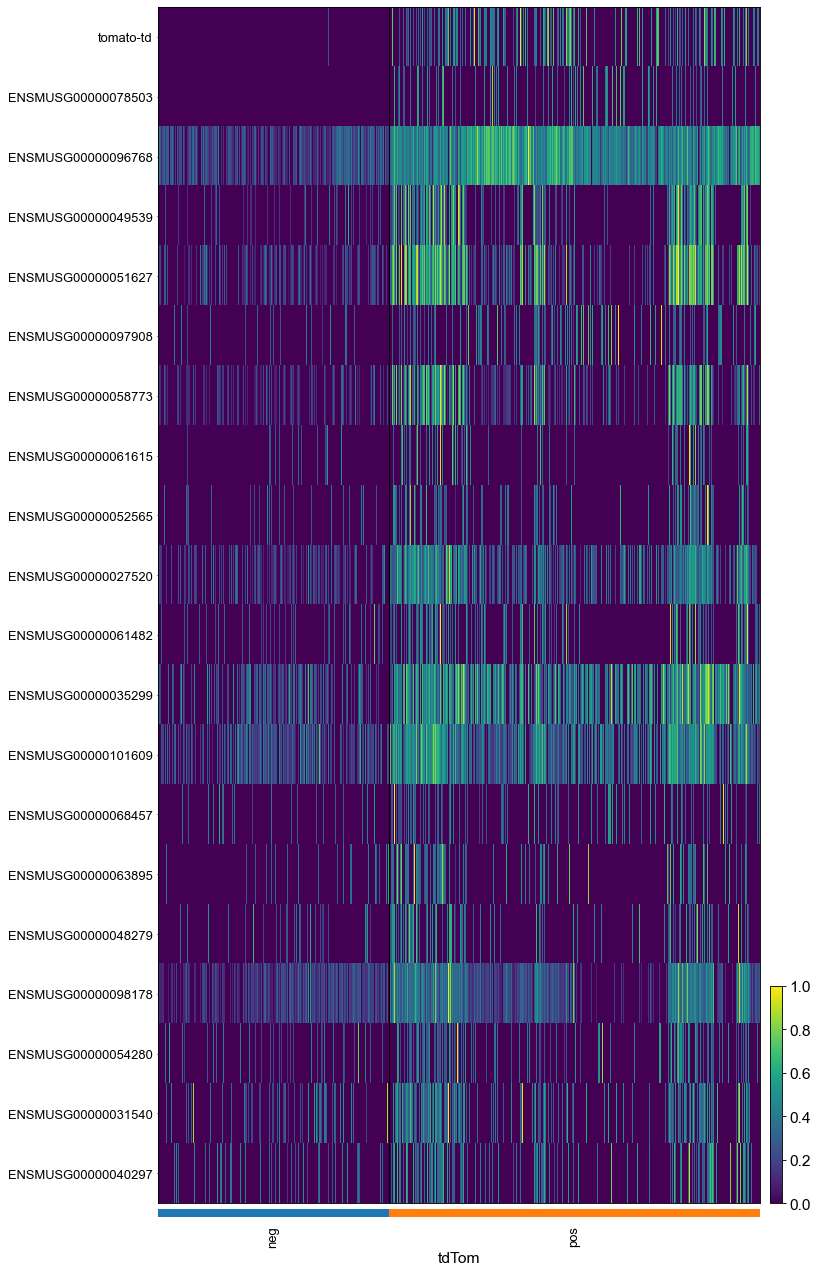

In [151]:
## different one to create DF only with gene names
#wt = pd.read_csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/data/wt_tomato_correlations_for_Melania.csv", index_col=1)
#list_names = [name for name in list(wt.index[0:100]) if name in adata.var_names]
sc.settings.figdir = 'C:/Users/aamw4/home/aamw4/plots/heatmaps/'
output_dr = 'C:/Users/aamw4/home/aamw4/plots/MAplots/'
number_genes = []
final = pd.DataFrame()

for pop in list(df_good.index):
    print(pop)
    adata_rid = adata[adata.obs['celltype.mapped'] == pop,:].copy()
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
    df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])

    
    vec_up = np.where((df3['pos']>=np.log2(1.5)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
    vec_down = np.where((df3['neg']>= np.log2(1.5)) & (df2['neg']<= 0.1) )[0]
    
        
    df_pos = pd.DataFrame(df2.loc[vec_up]['pos'])
    df_pos.index = list(df1.loc[vec_up]['pos'])
    df_pos['lfc'] = list(df3.loc[vec_up]['pos'])
    df_pos = df_pos.sort_values(by='lfc',ascending=False)
    df_pos['scores'] = list(df4.loc[vec_up]['pos'])

 
    df_neg = pd.DataFrame(df2.loc[vec_down]['neg'])
    df_neg.index = list(df1.loc[vec_down]['neg'])
    df_neg['lfc'] = list(df3.loc[vec_down]['neg'])
    df_neg = df_neg.sort_values(by='lfc',ascending=False)
    df_neg['scores'] = list(df4.loc[vec_down]['pos'])

 
    lista_n = df_neg.index
    lista_p = df_pos.index
 
    print(len(lista_p))
    print(len(lista_n))
    
    number_pos = len(lista_p)
    number_neg = len(lista_n)
    
    number_genes.append(number_pos)
    number_genes.append(number_neg)
    
    #make a list with lengths of all lists, sort and take maximum
    
    list_pos = lista_p.tolist() #format to list to add to dataframe
    list_neg = lista_n.tolist()
    
    #create DataFrame final with only gene names according to celltype and tdTom 
    
    df_posi = pd.DataFrame({'pos': list_pos})
    df_nega = pd.DataFrame({'neg': list_neg})
    
    
    columns = create_tuple_for_for_columns(df_posi, pop)
    df_posi.columns = pd.MultiIndex.from_tuples(columns)
    
    index = pd.MultiIndex.from_tuples(df_posi, names=['celltype', 'tdTom'])
    df_posi.columns = index
    
    columns = create_tuple_for_for_columns(df_nega, pop)
    df_nega.columns = pd.MultiIndex.from_tuples(columns)
    
    index = pd.MultiIndex.from_tuples(df_nega, names=['celltype', 'tdTom'])
    df_nega.columns = index 

    df_pn = pd.concat([df_posi, df_nega], axis=1)
    index = pd.MultiIndex.from_tuples(df_pn, names=['celltype', 'tdTom'])
    df_pn.columns = index
    
    final = pd.concat([final, df_pn], axis=1)
    
    #heatmaps
    adata_rid.var_names_make_unique()
    
    if len(df_posi) > 20:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,0].head(20), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_pos.png' )
    else : 
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,0].head(len(df_posi)), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_pos.png' )
            
    if len(df_nega) > 20:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,1].head(20), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_neg.png' )
    else:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,1].head(len(df_nega)), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_neg.png' )
    
    #ranks for GSEA
    ll = list(df1.pos)
    lista = [x.upper() for x in ll]
    df = pd.DataFrame(lista)
    df['score'] = df4.iloc[:,0]
    df.to_csv(output_dr + '{}'.format(pop)+'KOpos_vs_KOneg.rnk',sep = '\t', header=None, index=None)
    
    
print('finished ranking genes')
number_genes.sort(reverse=True)
number_genes[0] #prints highest number of selected genes for any celltype population to adapt range accordingly of df-Dea in initialisation

In [152]:
final.to_csv(output_dr + 'wt_chim_DEGs_final')

# DEG for WT injected cells

In [34]:
adata_wt.obs['tomato'] = adata_wt.obs['tomato'].replace([0, 1],['neg','pos'])

In [35]:
df = pd.crosstab(adata_wt.obs['celltype.mapped'], adata_wt.obs['tomato'])
#df = df.rename(columns={0: "neg", 1: "pos"})
vec = np.array((df.neg>=50) & (df.pos>=50))
print(vec)
df_good_wt = df.loc[vec] #df.iloc[vec] does not work for one reason I don't understand, but df.loc[voc] takes away index
print(df_good_wt)
print(df_good_wt.dtypes)


[False False  True  True False  True  True False False  True False  True
 False False  True False False  True  True  True  True  True  True  True
  True  True False False False  True False  True  True  True  True  True
 False  True False]
tomato                          neg   pos
celltype.mapped                          
Blood progenitors 1              96    89
Blood progenitors 2             212   236
Caudal Mesoderm                  95   174
Caudal epiblast                 248   428
Doublet                         282   574
Epiblast                        222   225
Erythroid3                      164   253
ExE mesoderm                     85   263
Forebrain/Midbrain/Hindbrain    143   256
Gut                             194   244
Haematoendothelial progenitors  201   296
Intermediate mesoderm           166   335
Mesenchyme                      456  1025
Mixed mesoderm                   75   103
NMP                              66   124
Nascent mesoderm                137   166
Parax

In [25]:
list_common = [pop for pop in df_good.index if pop in df_good_wt.index]

NameError: name 'df_good_wt' is not defined

In [37]:
list_common

['Blood progenitors 1',
 'Blood progenitors 2',
 'Caudal Mesoderm',
 'Erythroid3',
 'ExE mesoderm',
 'Forebrain/Midbrain/Hindbrain',
 'Gut',
 'Intermediate mesoderm',
 'Mesenchyme',
 'NMP',
 'Paraxial mesoderm',
 'Pharyngeal mesoderm',
 'Somitic mesoderm',
 'Spinal cord',
 'Surface ectoderm']

In [38]:
def create_tuple_for_for_columns(df_a, multi_level_col):
    """
    Create a columns tuple that can be pandas MultiIndex to create multi level column

    :param df_a: pandas dataframe containing the columns that must form the first level of the multi index
    :param multi_level_col: name of second level column
    :return: tuple containing (second_level_col, firs_level_cols)
    """
    temp_columns = []
    for item in df_a.columns:
        temp_columns.append((multi_level_col, item))
    return temp_columns

In [39]:
#sc.settings.figdir = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/heatmaps/'
ran = range(0,519)
df_dea = pd.DataFrame().reindex(ran) #initialization of df_dea #ValueError: Cannot set a frame with no defined index and a value that cannot be converted to a Series
df_dea.dropna(inplace=True)
number_genes = []


for pop in list(list_common):
    print(pop)
    adata_rid = adata_wt[adata_wt.obs['celltype.mapped'] == pop,:].copy()
    sc.tl.rank_genes_groups(adata_rid, groupby='tomato', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df5 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df6 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df7 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])

    
    vec_up = np.where((df7['pos']>=np.log2(1.5)) & (df6['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
    vec_down = np.where((df7['neg']>= np.log2(1.5)) & (df6['neg']<= 0.1) )[0]
    
        
    df_pos = pd.DataFrame(df6.loc[vec_up]['pos'])
    df_pos.index = list(df5.loc[vec_up]['pos'])
    df_pos['lfc'] = list(df7.loc[vec_up]['pos'])
    df_pos = df_pos.sort_values(by='lfc',ascending=False)

 
    df_neg = pd.DataFrame(df6.loc[vec_down]['neg'])
    df_neg.index = list(df5.loc[vec_down]['neg'])
    df_neg['lfc'] = list(df7.loc[vec_down]['neg'])
    df_neg = df_neg.sort_values(by='lfc',ascending=False)

 
    lista_n = df_neg.index
    lista_p = df_pos.index
 
    print(len(lista_p))
    print(len(lista_n))
    
    number_pos = len(lista_p)
    number_neg = len(lista_n)
    
    number_genes.append(number_pos)
    number_genes.append(number_neg)
    
    #make a list with lengths of all lists, sort and take maximum
    
    list_pos = lista_p.tolist() #format to list to add to dataframe
    list_neg = lista_n.tolist()
    
    ##create df_dea with gene names, pvaladj and lfc
           
    df_dea[pop + '_pos_g'] = pd.Series(list_pos) #to avoid errors from different lengths, convert to Series
    df_dea[pop + '_pos_pvaladj'] = pd.Series(list(df_pos['pos']))
    df_dea[pop + '_pos_lfc'] = pd.Series(list(df_pos['lfc']))
    
    
    df_dea[pop + '_neg_g'] = pd.Series(list_neg)
    df_dea[pop + '_neg_pvaladj'] = pd.Series(list(df_neg['neg']))
    df_dea[pop + '_neg_lfc'] = pd.Series(list(df_neg['lfc']))
    
        
print('finished ranking genes')
number_genes.sort(reverse=True)
number_genes[0] #prints highest number of selected genes for any celltype population to adapt range accordingly of df-Dea in initialisation

Blood progenitors 1
ranking genes


... storing 'celltype.mapped' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tomato' as categorical
... storing 'gene_symbols' as categorical


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
7
12
Blood progenitors 2
ranking genes


... storing 'celltype.mapped' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tomato' as categorical
... storing 'gene_symbols' as categorical


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
19
32
Caudal Mesoderm
ranking genes


...

... storing 'celltype.mapped' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tomato' as categorical
... storing 'gene_symbols' as categorical


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
261
74
Surface ectoderm
ranking genes


... storing 'celltype.mapped' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tomato' as categorical
... storing 'gene_symbols' as categorical


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)
22
29
finished ranking genes


519

In [40]:
df_dea.to_csv('C:/Users/aamw4/home/aamw4/wt_DEGs_df_dea.csv')

# MA plot showing DEGs WT injection relative to chimera

In [41]:
final = pd.read_csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/results/chim_DEGs_final", header = [0,1], sep = ",")
df_chim = pd.read_csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/results/chim_DEGs_df_dea")
df_wt = pd.read_csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/results/wt_DEGs_df_dea.csv")


In [42]:
unique_genes = pd.DataFrame()
for pop in list_common:    
    dfn = [gene for gene in list(df_chim[pop + '_neg_g']) if gene not in list(df_wt[pop + '_neg_g'])]
    dfp = [gene for gene in list(df_chim[pop + '_pos_g']) if gene not in list(df_wt[pop + '_pos_g'])]
    unique_genes[pop + '_neg_g'] = pd.Series(dfn)
    unique_genes[pop + '_pos_g'] = pd.Series(dfp)
unique_genes

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  


,Blood progenitors 1_neg_g,Blood progenitors 1_pos_g,Blood progenitors 2_neg_g,Blood progenitors 2_pos_g,Caudal Mesoderm_neg_g,Caudal Mesoderm_pos_g,Erythroid3_neg_g,Erythroid3_pos_g,ExE mesoderm_neg_g,ExE mesoderm_pos_g,...,Paraxial mesoderm_neg_g,Paraxial mesoderm_pos_g,Pharyngeal mesoderm_neg_g,Pharyngeal mesoderm_pos_g,Somitic mesoderm_neg_g,Somitic mesoderm_pos_g,Spinal cord_neg_g,Spinal cord_pos_g,Surface ectoderm_neg_g,Surface ectoderm_pos_g
0,Grb10,NaN,Clec1b,H19,Grb10,Nnat,Grb10,Mcts2,Grb10,Gm13225,...,Grb10,4933404O12Rik,Hbb-y,4933404O12Rik,Grb10,Nap1l5,Grb10,Impact,Grb10,Gm13225
1,Hbb-y,NaN,Tmsb4x,Fabp5,Hbb-y,mt-Co1,Hbb-y,Aurka,Hbb-y,4933404O12Rik,...,Pitx2,Fgf18,Grb10,Xlr3b,Hbb-y,Nnat,Rab6b,Peg10,Hbb-y,Xlr3b
2,Hba-x,NaN,Hbb-y,Smad7,Hba-x,NaN,Scand1,Actg1,Hba-a1,Gm13154,...,Igf2r,Hoxb1,Tlx1,Plagl1,Hba-x,Osbpl1a,Pdxdc1,Nnat,Hba-x,Peg10
3,Car2,NaN,Plek,Peg3,Ccnd2,NaN,Hba-a2,Shmt2,Hba-x,Nap1l5,...,Foxl2,Aldh1a2,Zim1,Peg3,Hba-a2,Peg3,DHRSX,H19,Hba-a1,Peg3
4,Hbb-bh1,NaN,Rgs18,Bex1,Rpl21,NaN,Hemgn,Bex1,Hba-a2,Xlr3b,...,Nefm,Meox1,Nkx2-6,Hoxb6,Hba-a1,Mest,Lamtor3,Mcts2,Hba-a2,Slc38a4
5,Unc119,NaN,Rac2,Homer2,NaN,NaN,Bpgm,Rraga,Hbb-bs,Peg10,...,Ndnf,Aldoc,Hba-x,Hoxaas3,Igf2r,Clcn5,Gcsh,Sgce,Igf2r,Airn
6,Tomm22,NaN,Fcer1g,Mdk,NaN,NaN,Hba-a1,Rap1b,Igf2r,Cdk5rap1,...,Lum,Tcf15,Six2,Peg10,Hbb-bh1,H19,Tomm22,Slc38a4,Hbb-bh1,Nnat
7,S100a10,NaN,Pdlim1,Hmga2,NaN,NaN,Rpl21,NaN,Hbb-bh1,Peg3,...,Ddr2,Hoxa5,Hba-a2,Rspo3,Miip,P4ha2,Rpl21,NaN,Rab6b,Cdx1
8,Apoe,NaN,Fyb,Mest,NaN,NaN,Gmpr,NaN,Rab32,Usp29,...,Gng11,Arg1,Hba-a1,Slc38a4,DHRSX,NaN,Miip,NaN,Wfdc2,Usp29
9,Rpl21,NaN,Prkcq,Scd2,NaN,NaN,Sf3b5,NaN,Igf2,Gm21887,...,Car4,Hoxb4,Fgf8,Sh3bgr,Tomm22,NaN,1190007I07Rik,NaN,Sostdc1,PISD


In [43]:
unique_genes.to_csv(out_folder + 'DEG_unique_genes.csv')

In [66]:
overlap_genes = pd.DataFrame()
for pop in list_common:    
    dfn = [gene for gene in list(df_chim[pop + '_neg_g']) if gene in list(df_wt[pop + '_neg_g'])]
    dfp = [gene for gene in list(df_chim[pop + '_pos_g']) if gene in list(df_wt[pop + '_pos_g'])]
    overlap_genes[pop + '_neg_g'] = pd.Series(dfn)
    overlap_genes[pop + '_pos_g'] = pd.Series(dfp)
overlap_genes

,Blood progenitors 1_neg_g,Blood progenitors 1_pos_g,Blood progenitors 2_neg_g,Blood progenitors 2_pos_g,Caudal Mesoderm_neg_g,Caudal Mesoderm_pos_g,Erythroid3_neg_g,Erythroid3_pos_g,ExE mesoderm_neg_g,ExE mesoderm_pos_g,...,Paraxial mesoderm_neg_g,Paraxial mesoderm_pos_g,Pharyngeal mesoderm_neg_g,Pharyngeal mesoderm_pos_g,Somitic mesoderm_neg_g,Somitic mesoderm_pos_g,Spinal cord_neg_g,Spinal cord_pos_g,Surface ectoderm_neg_g,Surface ectoderm_pos_g
0,H13,Impact,Grb10,4933404O12Rik,Cdkn1c,Erdr1,Slc4a1,Erdr1,Cdkn1c,Nfkbiz,...,Cdkn1c,Erdr1,Cdkn1c,Impact,Cdkn1c,Erdr1,Cdkn1c,4933404O12Rik,Cdkn1c,4933404O12Rik
1,Scand1,Erdr1,Akr1e1,Impact,Phlda2,NaN,NaN,Impact,Xist,Impact,...,Hbb-y,Impact,Phlda2,Erdr1,Phlda2,Impact,Hbb-y,Erdr1,Xist,Impact
2,NaN,Kcnq1ot1,H13,Erdr1,NaN,NaN,NaN,Kcnq1ot1,Phlda2,Erdr1,...,Phlda2,Mid1,Akr1e1,Mid1,Akr1e1,Mid1,Hba-x,Mid1,Phlda2,Erdr1
3,NaN,NaN,Lamtor3,Mid1,NaN,NaN,NaN,Peg3,Akr1e1,Mcts2,...,Hba-a1,Mcts2,H13,Mcts2,H13,Kcnq1ot1,Akr1e1,Kcnq1ot1,Akr1e1,Kcnq1ot1
4,NaN,NaN,Sla2,Kcnq1ot1,NaN,NaN,NaN,Ciapin1,H13,Slc38a4,...,Hba-x,Kcnq1ot1,Scand1,Kcnq1ot1,B230312C02Rik,Slc38a4,Hba-a2,Peg3,H13,Mid1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
188,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
overlap_genes.to_csv(out_folder + 'DEG_overlap_genes_chim_wt_injection.csv')

In [67]:
list_common

['Blood progenitors 1',
 'Blood progenitors 2',
 'Caudal Mesoderm',
 'Erythroid3',
 'ExE mesoderm',
 'Forebrain/Midbrain/Hindbrain',
 'Gut',
 'Intermediate mesoderm',
 'Mesenchyme',
 'NMP',
 'Paraxial mesoderm',
 'Pharyngeal mesoderm',
 'Somitic mesoderm',
 'Spinal cord',
 'Surface ectoderm']

In [68]:
pop = 'Blood progenitors 2' #put celltype here
adata_rid = adata[adata.obs['celltype.mapped'] == pop,:].copy() 
sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', n_genes=10000, key = "wilcoxon")
df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])


ranking genes


... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


In [69]:
pop

'Blood progenitors 2'

In [70]:
df2.index = list(df1.pos)

In [71]:
df5 = df2.copy()

In [72]:
df5.index = list(df1.neg)

In [ ]:
## foldchange = []
mean = []
foldchange = []
foldchange_sig = [] #to highlight significant genes
mean_sig = []
mean_wti = []
flc_wti = []
genes_sig = []
dfn = [str(x) for x in list(overlap_genes[pop + '_neg_g']) if str(x)!='nan']
dfp = [str(x) for x in list(overlap_genes[pop + '_pos_g']) if str(x)!='nan']


for i in df2.index[:10]: #len(adata_rid.var_names
     mean_wt = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'neg',i].X) #mean expression in WT
     mean_ko = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'pos',i].X) #mean expression in KO
     fc = np.log2(mean_ko/mean_wt)    #foldchange
     av = (mean_wt*mean_ko) #average expression
     #av = mean_wt #or just this
     foldchange.append(fc)
     mean.append(av)
        
    
     if df2.loc[i][0] < 0.1 and fc > 1:
         foldchange_sig.append(fc)
         mean_sig.append(av)
         genes_sig.append(i)
            
         if i in dfp:
             mean_wti.append(av)
             flc_wti.append(fc)
            
for i in df5.index[:10]: #len(adata_rid.var_names
     mean_wt = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'neg',i].X) #mean expression in WT
     mean_ko = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'pos',i].X) #mean expression in KO            
     fc1 = np.log2(mean_ko/mean_wt)    #foldchange
     av1 = (mean_ko*mean_wt) #average expression
     #av = mean_wt #or just this
     foldchange.append(fc1)
     mean.append(av1)
           

     if df5.loc[i][1] < 0.1 and fc1 < -1:
         foldchange_sig.append(fc1)
         mean_sig.append(av1)
         genes_sig.append(i)
         
     
         if i in dfn:
             mean_wti.append(av1)
             flc_wti.append(fc1)
                 

#now plot
plt.figure(figsize=(5,5))
plt.plot(mean, foldchange, 'k.')
plt.plot(mean_sig, foldchange_sig, 'r.') 
plt.plot(mean_wti, flc_wti, 'v')
for i in range(len(genes_sig)):
    plt.annotate(genes_sig[i], (mean_sig[i], foldchange_sig[i]))
plt.xlabel('Mean')
plt.ylabel('Log foldchange')
plt.title(pop)
plt.xscale('symlog', basex=2)
#plt.show()            

In [99]:
plt.savefig(out_folder + '{}'.format(pop)+'_MAplot.png')

<Figure size 320x320 with 0 Axes>

In [101]:
np.log2(0.1)

-3.321928094887362

11

# meso_subclust

In [164]:
adata_wt.obs['meso.mapped'] = adata_wt.obs['meso.mapped'].astype(str)

In [165]:
np.unique(adata_wt.obs['meso.mapped'])

array(['Anterior-most_somites', 'Dermomyotome', 'Head_mesoderm',
       'Posterior-most_somites', 'Presomitic_mesoderm', 'Sclerotome',
       'nan'], dtype=object)

In [170]:
df = pd.crosstab(adata_wt.obs['meso.mapped'], adata_wt.obs['tdTom'])
vec = np.array((df.neg>=0) & (df.pos>=0))
print(vec)
df_good = df.loc[vec] 
print(df_good)
print(df_good.dtypes)

[ True  True  True  True  True  True  True]
tdTom                    neg   pos
meso.mapped                       
Anterior-most_somites     11    23
Dermomyotome               8    17
Head_mesoderm             14    47
Posterior-most_somites    14    33
Presomitic_mesoderm       15    33
Sclerotome                 4    16
nan                     5537  7709
tdTom
neg    int64
pos    int64
dtype: object


In [ ]:
df = pd.crosstab(adata.obs['haem_subclust.mapped'], adata.obs['tdTom'])
df

In [ ]:
def create_tuple_for_for_columns(df_a, multi_level_col):
    """
    Create a columns tuple that can be pandas MultiIndex to create multi level column

    :param df_a: pandas dataframe containing the columns that must form the first level of the multi index
    :param multi_level_col: name of second level column
    :return: tuple containing (second_level_col, firs_level_cols)
    """
    temp_columns = []
    for item in df_a.columns:
        temp_columns.append((multi_level_col, item))
    return temp_columns

In [ ]:
sc.settings.figdir = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/heatmaps/'
ran = range(0,77)
df_deg = pd.DataFrame().reindex(ran) #initialization of df_dea #ValueError: Cannot set a frame with no defined index and a value that cannot be converted to a Series
df_deg.dropna(inplace=True)
number_genes = []
final = pd.DataFrame()

for pop in list(df_good.index):
    print(pop)
    adata_rid = adata[adata.obs['haem_subclust.mapped'] == pop,:].copy()
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])

    
    vec_up = np.where((df3['pos']>=np.log2(1.5)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
    vec_down = np.where((df3['neg']>= np.log2(1.5)) & (df2['neg']<= 0.1) )[0]
    
        
    df_pos = pd.DataFrame(df2.loc[vec_up]['pos'])
    df_pos.index = list(df1.loc[vec_up]['pos'])
    df_pos['lfc'] = list(df3.loc[vec_up]['pos'])
    df_pos = df_pos.sort_values(by='lfc',ascending=False)

 
    df_neg = pd.DataFrame(df2.loc[vec_down]['neg'])
    df_neg.index = list(df1.loc[vec_down]['neg'])
    df_neg['lfc'] = list(df3.loc[vec_down]['neg'])
    df_neg = df_neg.sort_values(by='lfc',ascending=False)

 
    lista_n = df_neg.index
    lista_p = df_pos.index
 
    print(len(lista_p))
    print(len(lista_n))
    
    number_pos = len(lista_p)
    number_neg = len(lista_n)
    
    number_genes.append(number_pos)
    number_genes.append(number_neg)
    
    #make a list with lengths of all lists, sort and take maximum
    
    list_pos = lista_p.tolist() #format to list to add to dataframe
    list_neg = lista_n.tolist()
    
    #create DataFrame final with only gene names according to celltype and tdTom 
    
    df_posi = pd.DataFrame({'pos': list_pos})
    df_nega = pd.DataFrame({'neg': list_neg})
    
    
    columns = create_tuple_for_for_columns(df_posi, pop)
    df_posi.columns = pd.MultiIndex.from_tuples(columns)
    
    index = pd.MultiIndex.from_tuples(df_posi, names=['celltype', 'tdTom'])
    df_posi.columns = index
    
    columns = create_tuple_for_for_columns(df_nega, pop)
    df_nega.columns = pd.MultiIndex.from_tuples(columns)
    
    index = pd.MultiIndex.from_tuples(df_nega, names=['celltype', 'tdTom'])
    df_nega.columns = index 

    df_pn = pd.concat([df_posi, df_nega], axis=1)
    index = pd.MultiIndex.from_tuples(df_pn, names=['celltype', 'tdTom'])
    df_pn.columns = index
    
    final = pd.concat([final, df_pn], axis=1)
    
    adata_rid.var_names_make_unique()
    
    if len(df_posi) > 20:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,0].head(20), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_pos.png' )
    else : 
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,0].head(len(df_posi)), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_pos.png' )
            
    if len(df_nega) > 20:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,1].head(20), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_neg.png' )
    else:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,1].head(len(df_nega)), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_neg.png' )
   
    
print('finished ranking genes')
number_genes.sort(reverse=True)
number_genes[0] #prints highest number of selected genes for any celltype population to adapt range accordingly of df-Dea in initialisation

In [ ]:
final.to_csv('C:/Users/aamw4/home/aamw4/wt_chim_DEGs_haem.csv')

# Haem subclust

In [186]:
adata_wt.obs['haem_subclust.mapped'] = adata_wt.obs['haem_subclust.mapped'].astype(str)

np.unique(adata_wt.obs['haem_subclust.mapped'])

array(['BP1', 'BP2', 'BP3', 'BP4', 'EC1', 'EC2', 'EC3', 'EC4', 'EC5',
       'EC6', 'EC7', 'EC8', 'Ery1', 'Ery2', 'Ery3', 'Ery4', 'Haem1',
       'Haem2', 'Haem3', 'Haem4', 'Mes1', 'Mes2', 'Mk', 'My', 'nan'],
      dtype=object)

In [188]:
df = pd.crosstab(adata_wt.obs['haem_subclust.mapped'], adata_wt.obs['tdTom'])
vec = np.array((df.neg>=30) & (df.pos>=30))
print(vec)
df_good = df.loc[vec] #df.iloc[vec] does not work for one reason I don't understand, but df.loc[voc] takes away index
print(df_good)
print(df_good.dtypes)

[ True  True False False False  True False False False False False False
  True  True  True  True  True  True  True False False False False False
  True]
tdTom                  neg   pos
haem_subclust.mapped            
BP1                    120   138
BP2                    128   108
EC2                     71   129
Ery1                    31    58
Ery2                    59   150
Ery3                    85    83
Ery4                    57    77
Haem1                   34    33
Haem2                   72    91
Haem3                   58    52
nan                   4785  6733
tdTom
neg    int64
pos    int64
dtype: object


In [206]:
adata_wt.obs =  adata_wt.obs.drop(adata_wt.obs.columns[[34, 36, 38]], axis=1)

In [189]:
def create_tuple_for_for_columns(df_a, multi_level_col):
    """
    Create a columns tuple that can be pandas MultiIndex to create multi level column

    :param df_a: pandas dataframe containing the columns that must form the first level of the multi index
    :param multi_level_col: name of second level column
    :return: tuple containing (second_level_col, firs_level_cols)
    """
    temp_columns = []
    for item in df_a.columns:
        temp_columns.append((multi_level_col, item))
    return temp_columns

ranking genes
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


BP1


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-207-83c826f94100>:17: RuntimeWarning: divide by zero encountered in log2
  vec_up = np.where((df3['pos']>=np.log2(0)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
<ipython-input-207-83c826f94100>:18: RuntimeWarning: divide by zero encountered in log2
  vec_down = np.where((df3['neg']>= np.log2(0)) & (df2['neg']<= 0.1) )[0]


59
59


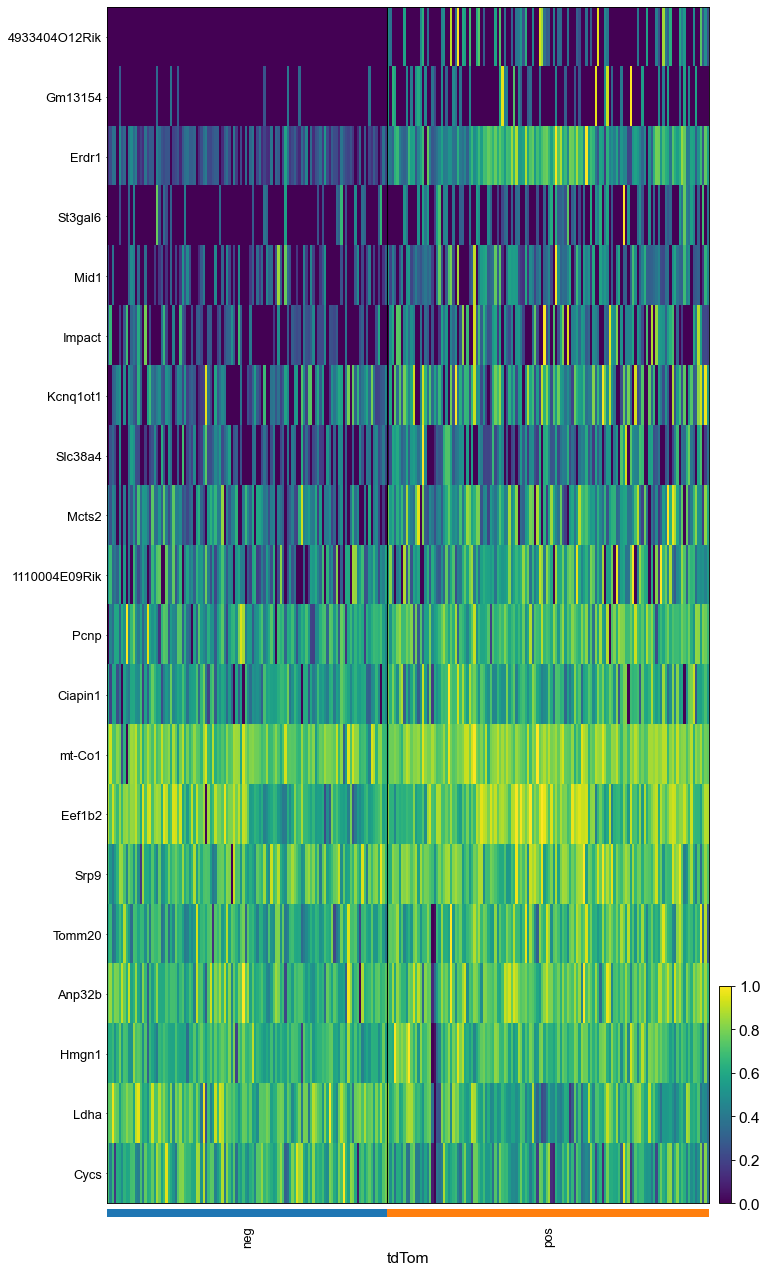

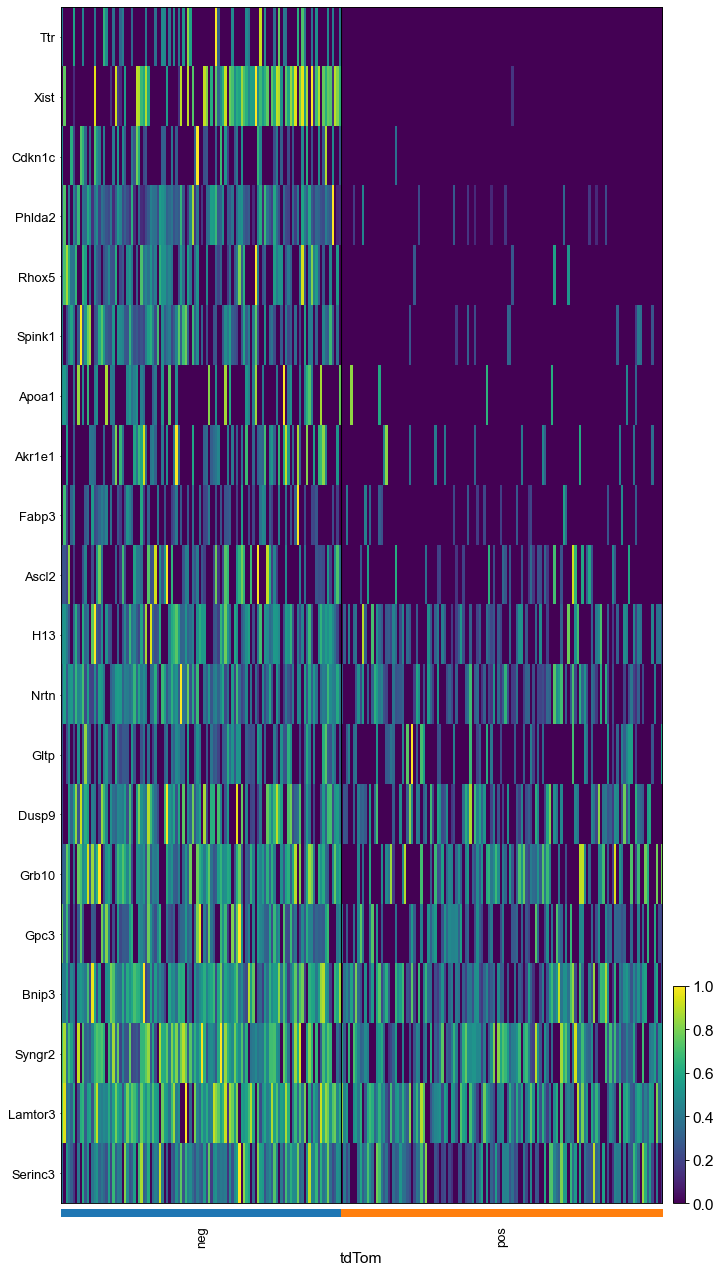

ranking genes
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


BP2


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-207-83c826f94100>:17: RuntimeWarning: divide by zero encountered in log2
  vec_up = np.where((df3['pos']>=np.log2(0)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
<ipython-input-207-83c826f94100>:18: RuntimeWarning: divide by zero encountered in log2
  vec_down = np.where((df3['neg']>= np.log2(0)) & (df2['neg']<= 0.1) )[0]


129
129


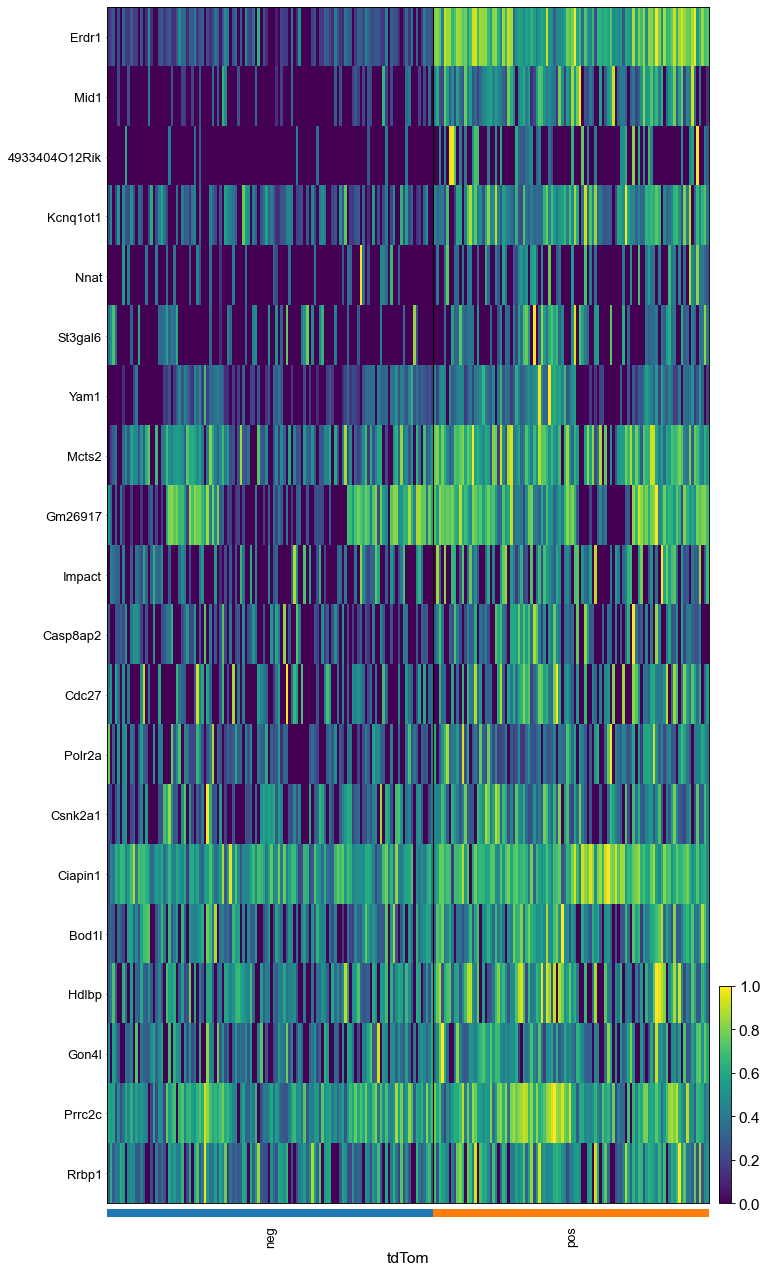

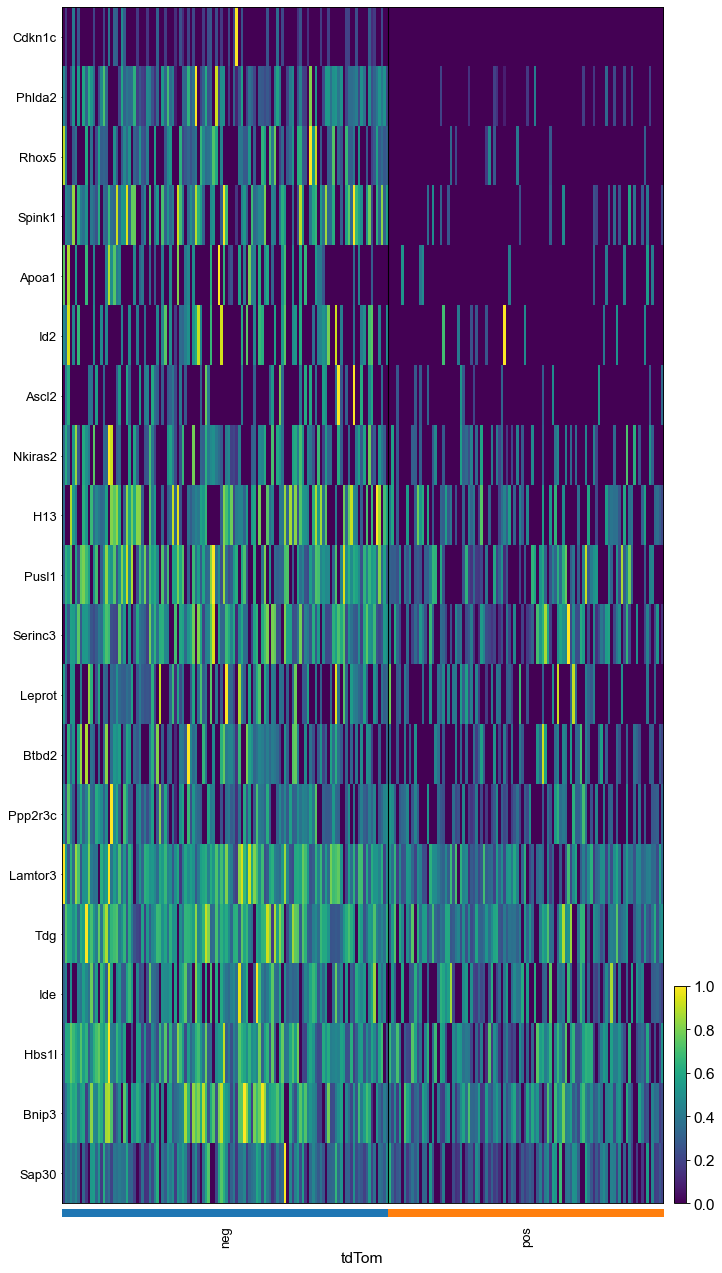

ranking genes
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


EC2


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-207-83c826f94100>:17: RuntimeWarning: divide by zero encountered in log2
  vec_up = np.where((df3['pos']>=np.log2(0)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
<ipython-input-207-83c826f94100>:18: RuntimeWarning: divide by zero encountered in log2
  vec_down = np.where((df3['neg']>= np.log2(0)) & (df2['neg']<= 0.1) )[0]


36
36


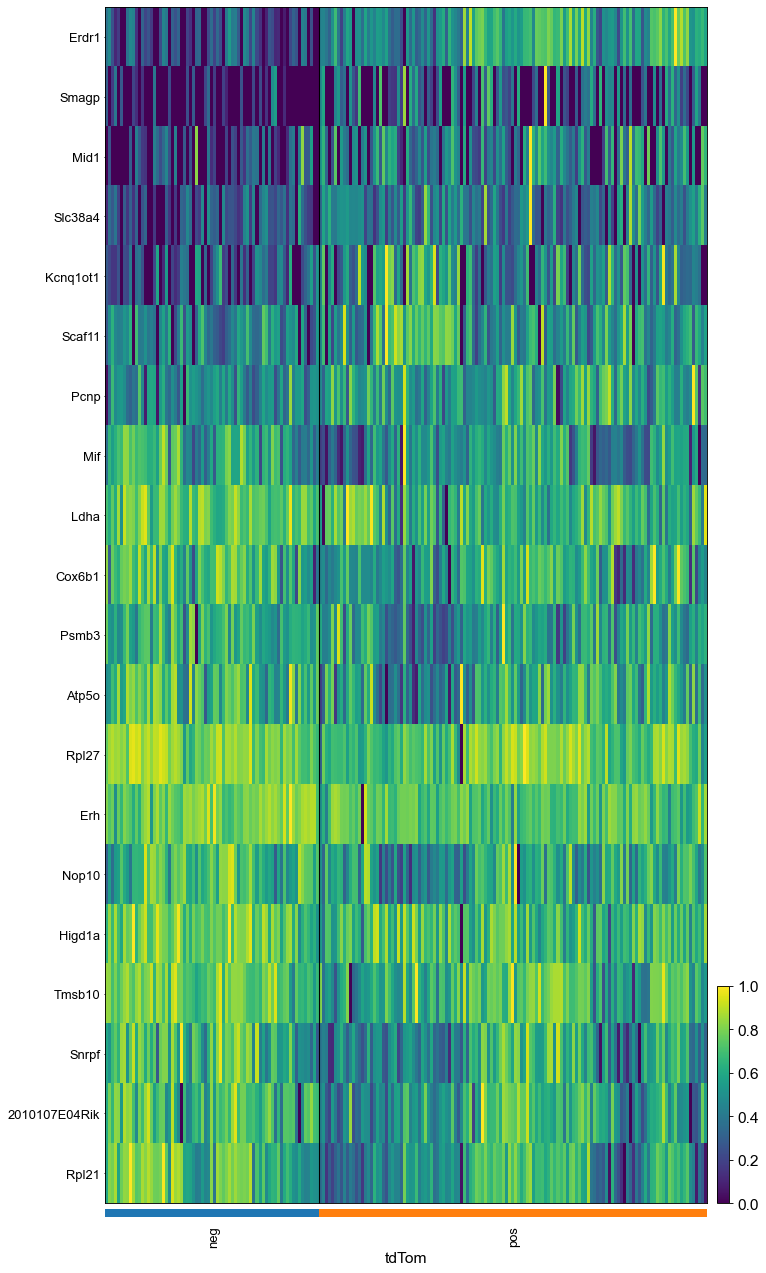

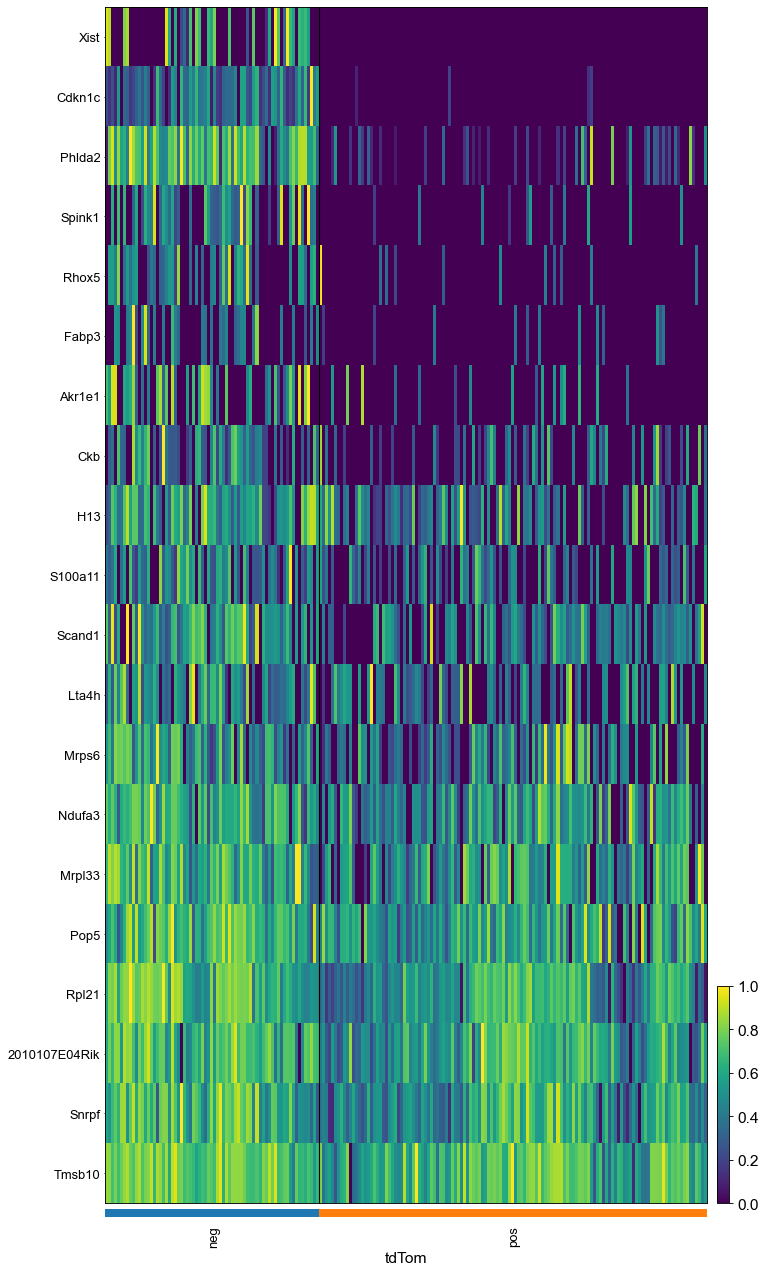

ranking genes
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


Ery1


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-207-83c826f94100>:17: RuntimeWarning: divide by zero encountered in log2
  vec_up = np.where((df3['pos']>=np.log2(0)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
<ipython-input-207-83c826f94100>:18: RuntimeWarning: divide by zero encountered in log2
  vec_down = np.where((df3['neg']>= np.log2(0)) & (df2['neg']<= 0.1) )[0]


240
240


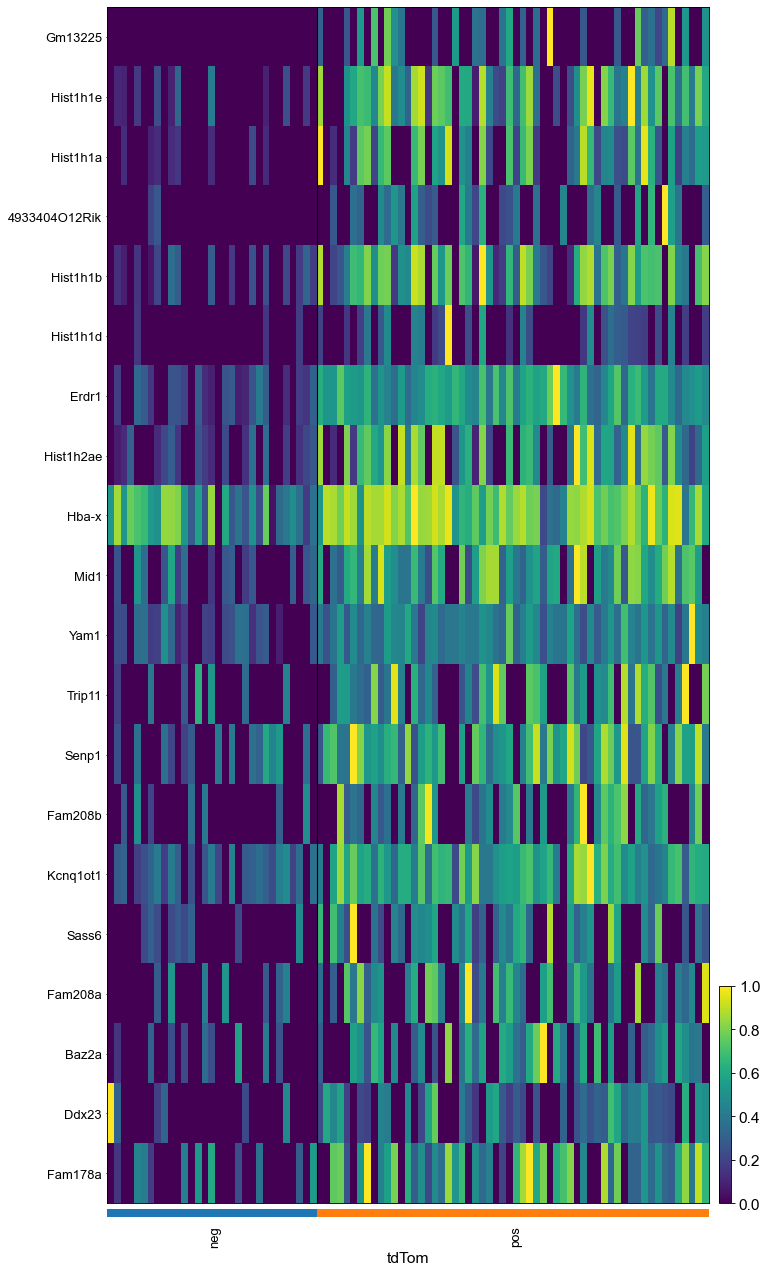

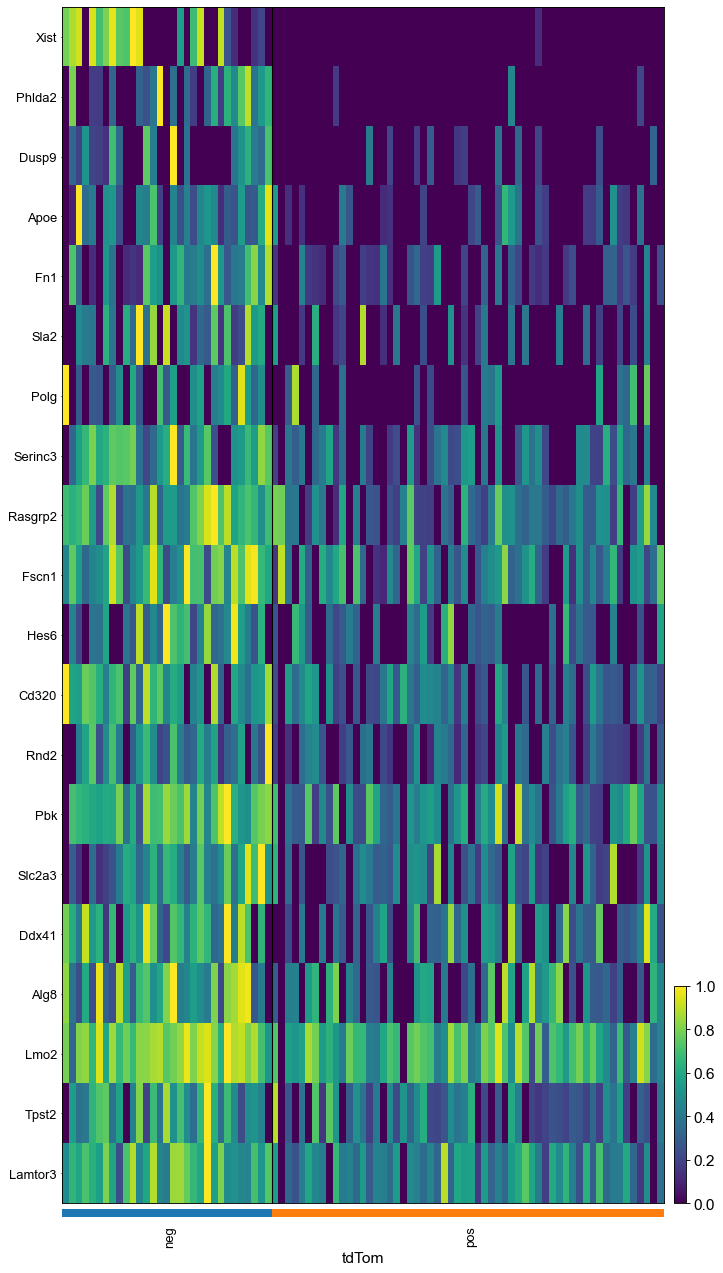

ranking genes
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


Ery2


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-207-83c826f94100>:17: RuntimeWarning: divide by zero encountered in log2
  vec_up = np.where((df3['pos']>=np.log2(0)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
<ipython-input-207-83c826f94100>:18: RuntimeWarning: divide by zero encountered in log2
  vec_down = np.where((df3['neg']>= np.log2(0)) & (df2['neg']<= 0.1) )[0]


892
892


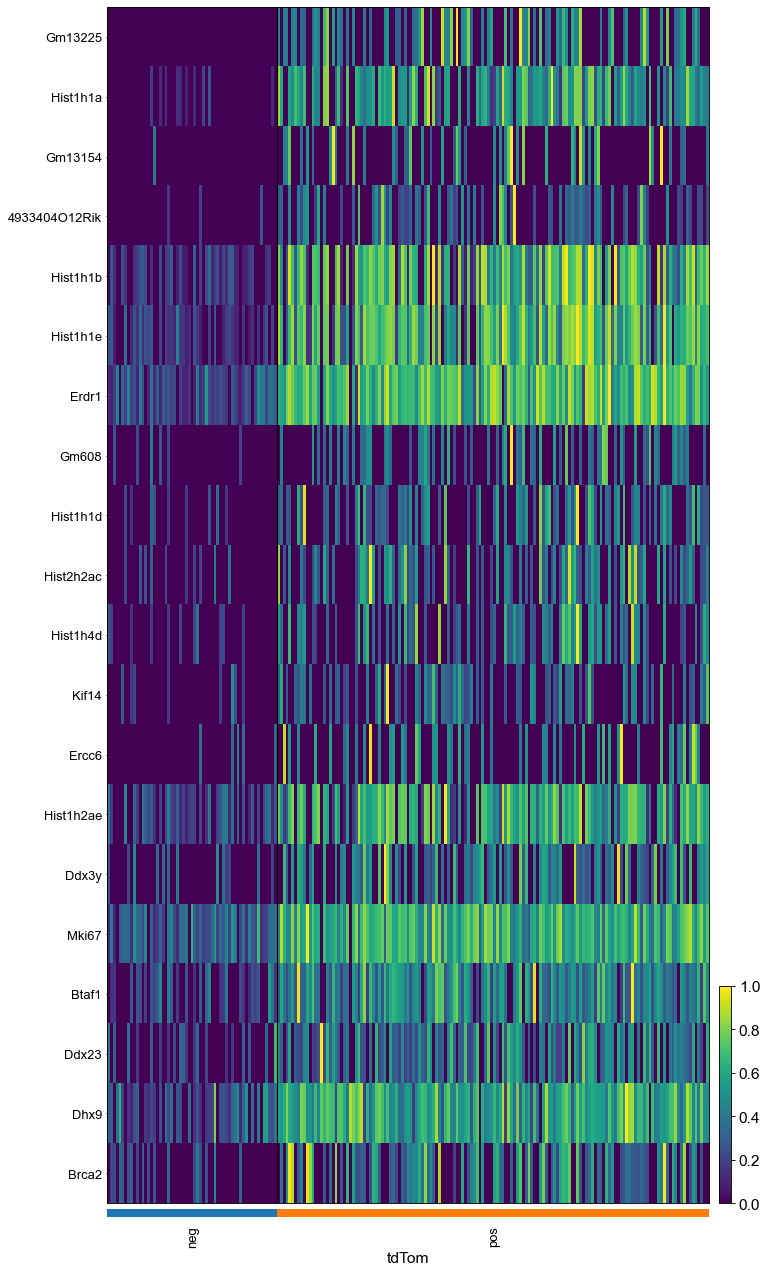

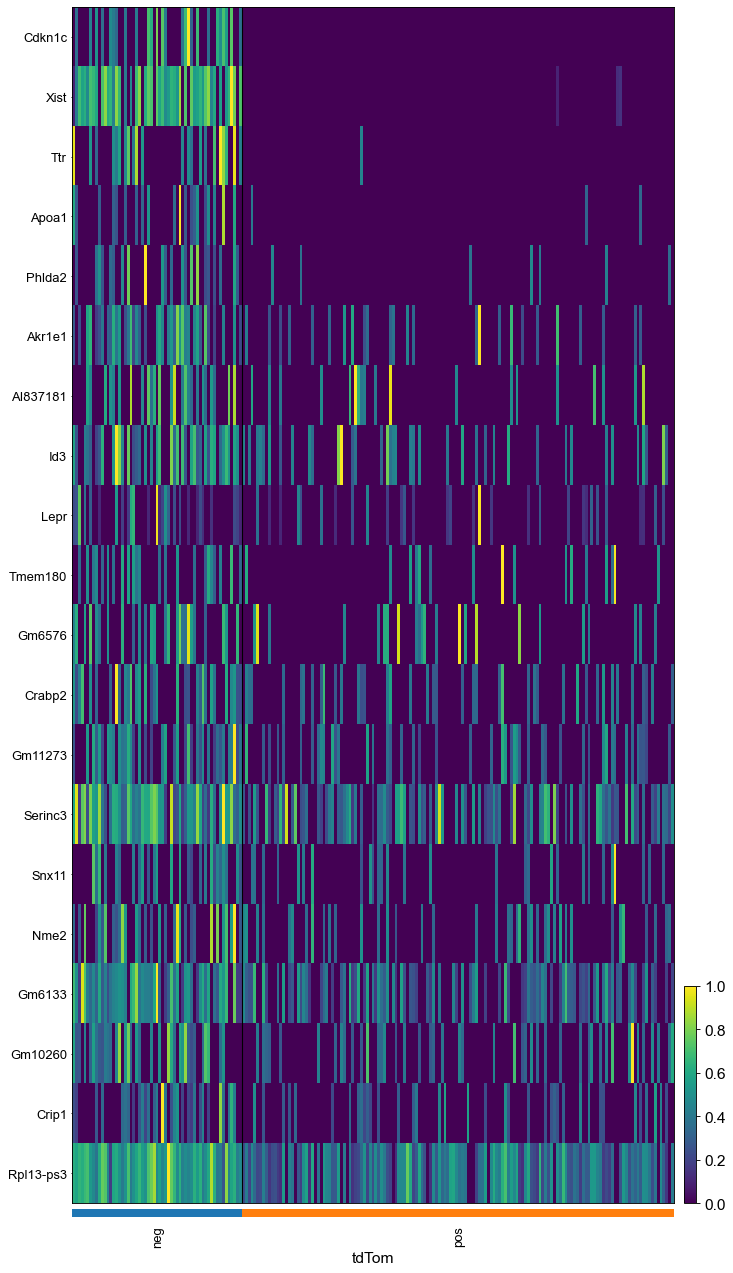

ranking genes
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


Ery3


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-207-83c826f94100>:17: RuntimeWarning: divide by zero encountered in log2
  vec_up = np.where((df3['pos']>=np.log2(0)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
<ipython-input-207-83c826f94100>:18: RuntimeWarning: divide by zero encountered in log2
  vec_down = np.where((df3['neg']>= np.log2(0)) & (df2['neg']<= 0.1) )[0]


950
950


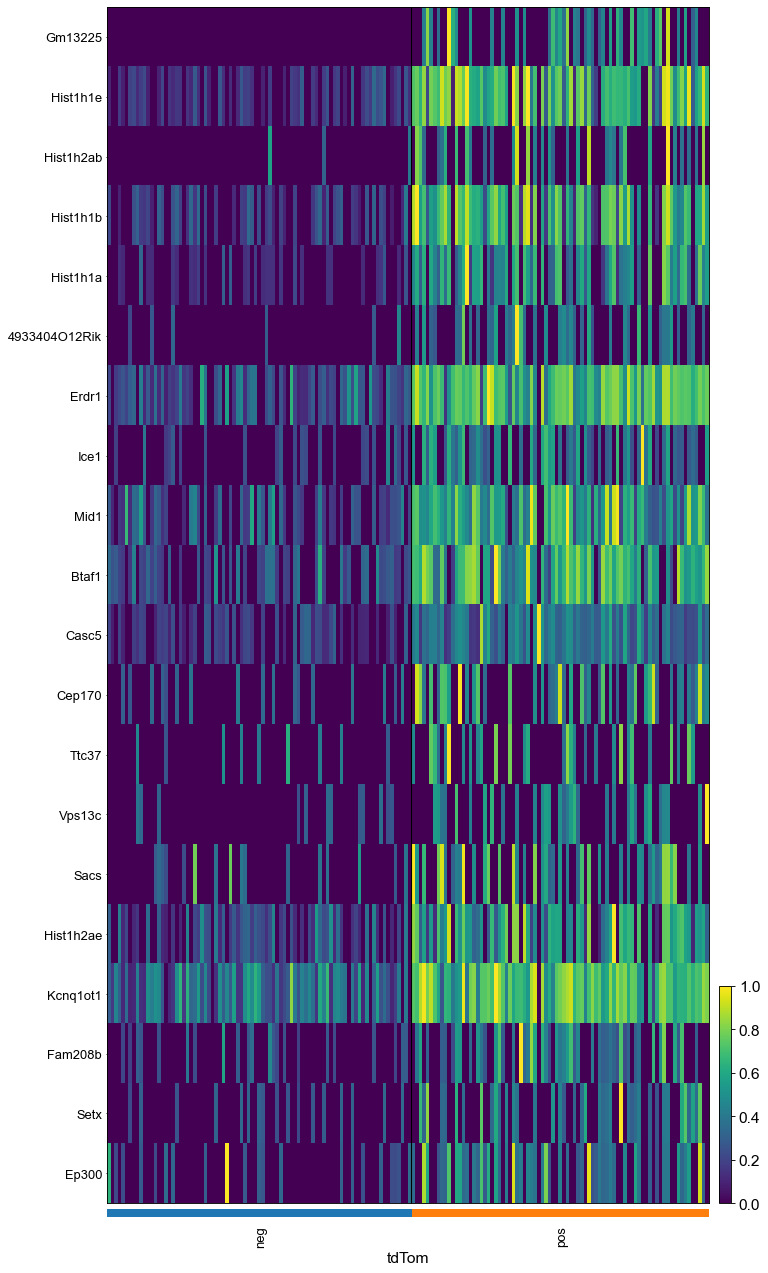

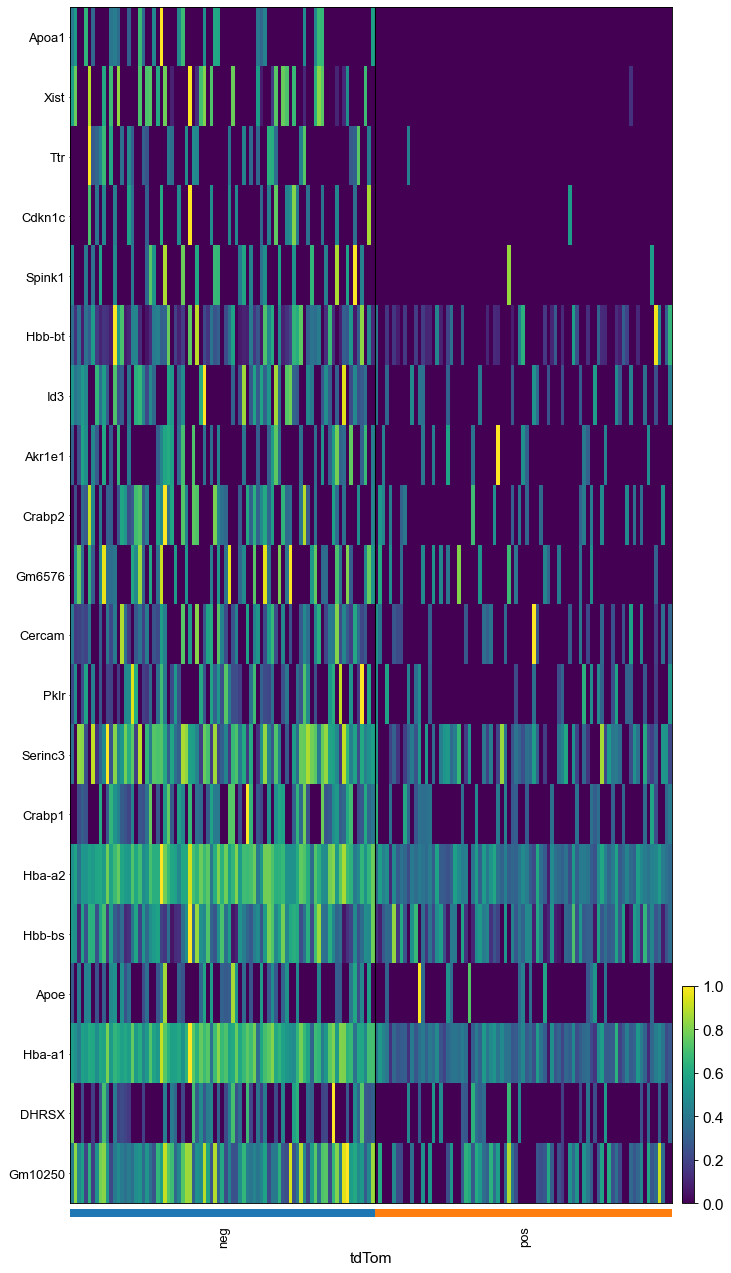

ranking genes
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


Ery4


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-207-83c826f94100>:17: RuntimeWarning: divide by zero encountered in log2
  vec_up = np.where((df3['pos']>=np.log2(0)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
<ipython-input-207-83c826f94100>:18: RuntimeWarning: divide by zero encountered in log2
  vec_down = np.where((df3['neg']>= np.log2(0)) & (df2['neg']<= 0.1) )[0]


542
542


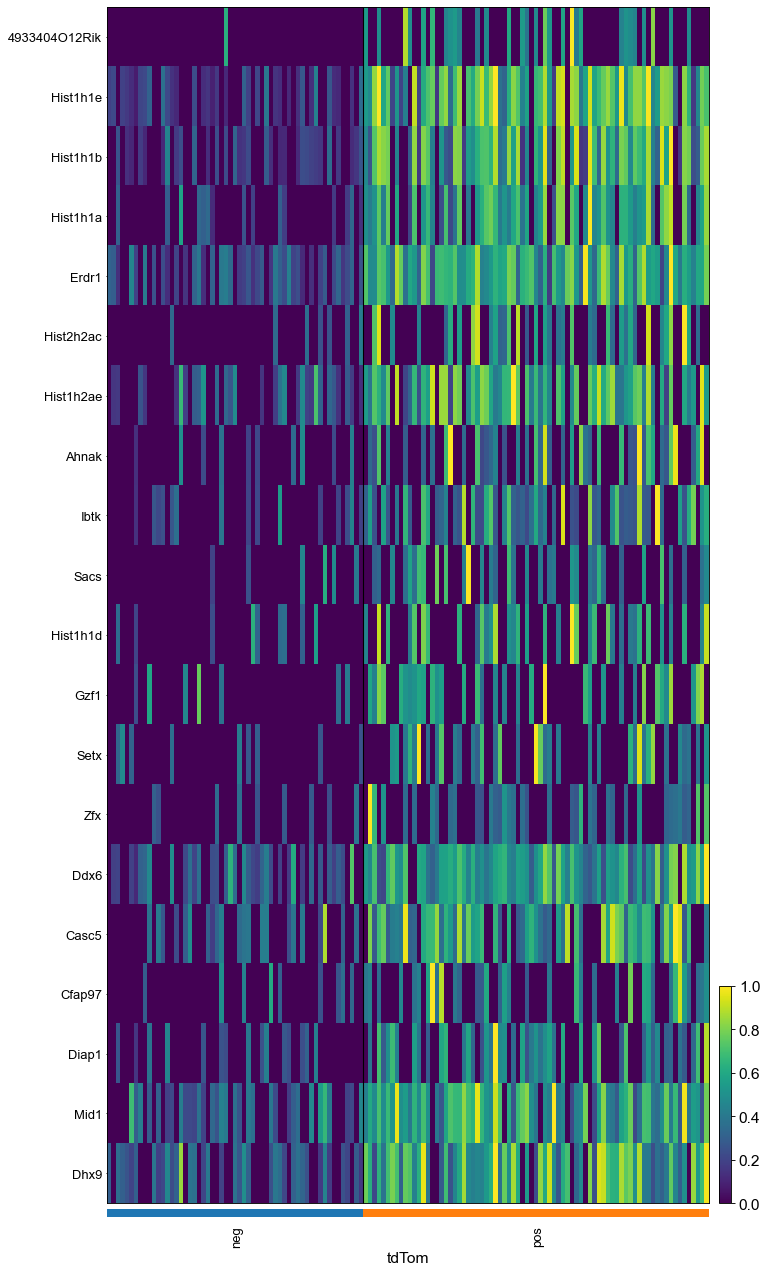

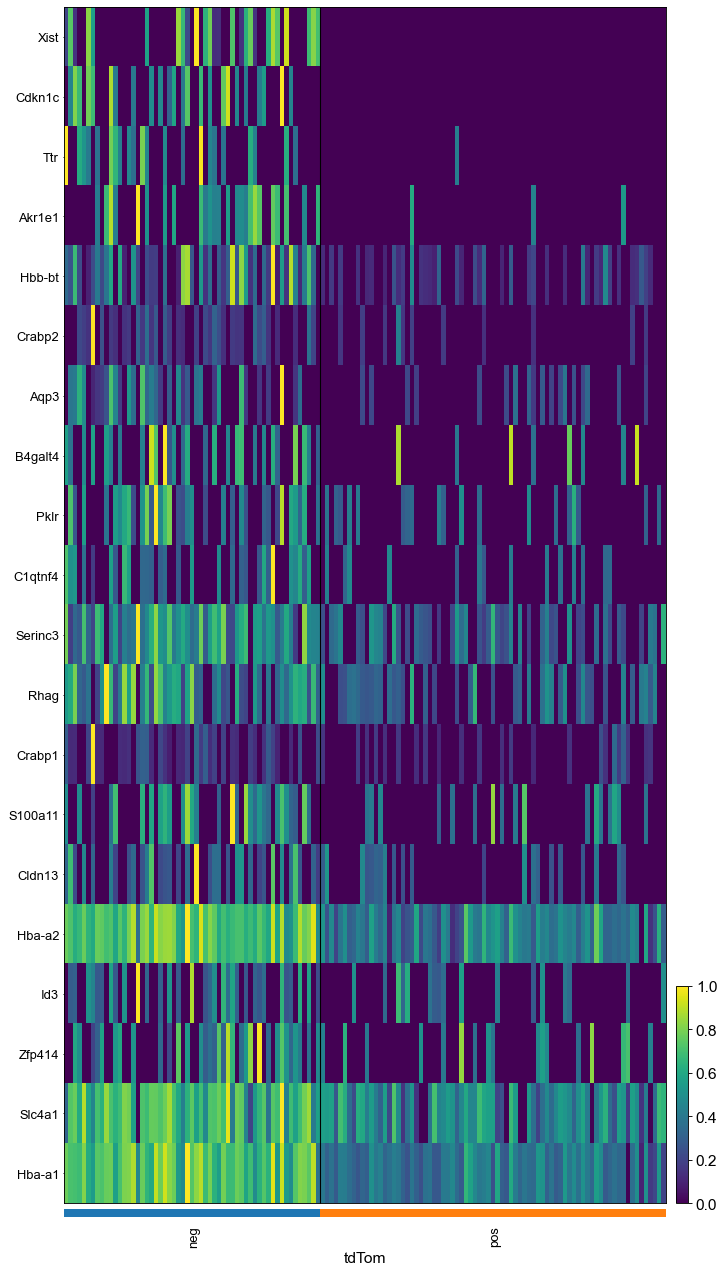

ranking genes
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


Haem1


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-207-83c826f94100>:17: RuntimeWarning: divide by zero encountered in log2
  vec_up = np.where((df3['pos']>=np.log2(0)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
<ipython-input-207-83c826f94100>:18: RuntimeWarning: divide by zero encountered in log2
  vec_down = np.where((df3['neg']>= np.log2(0)) & (df2['neg']<= 0.1) )[0]


6
6


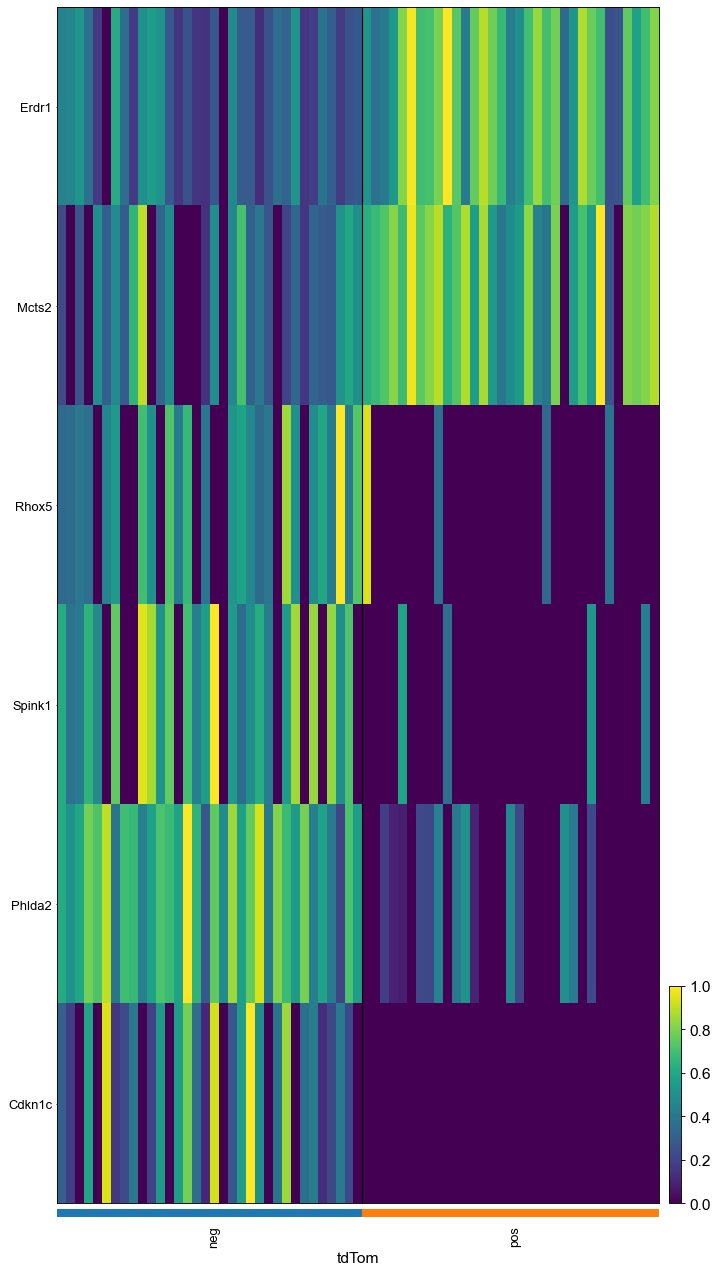

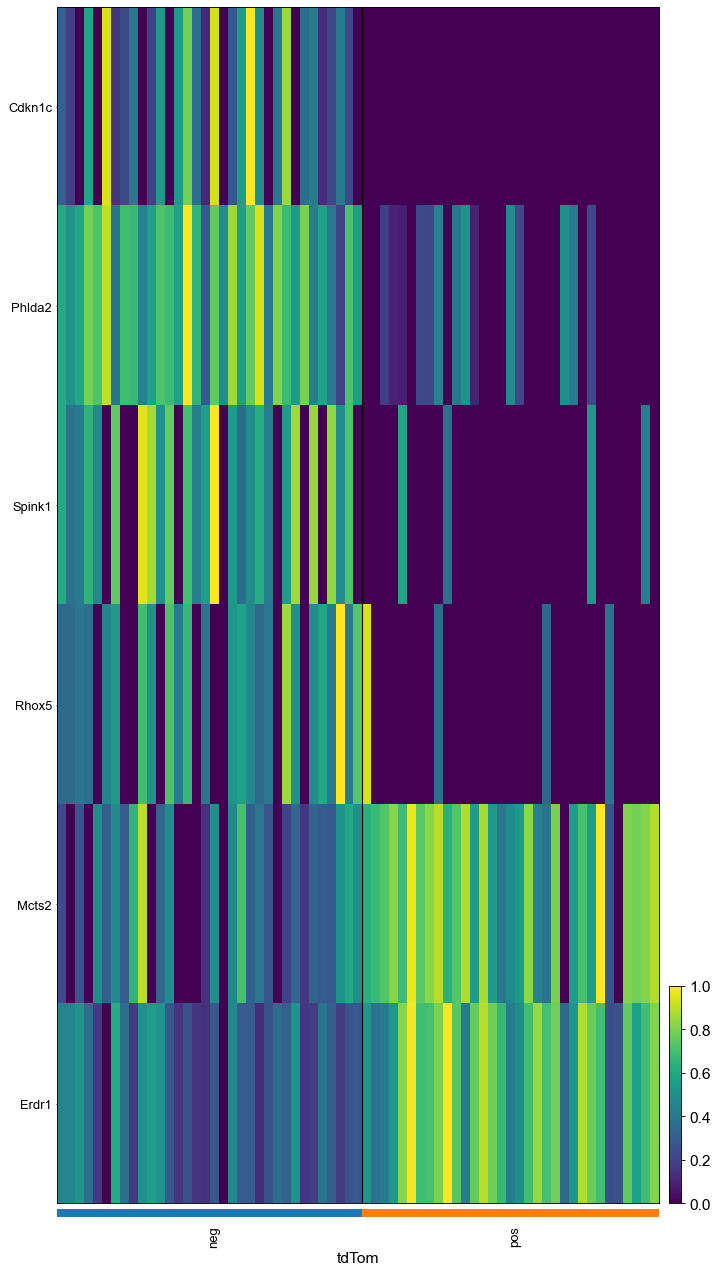

ranking genes
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


Haem2


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-207-83c826f94100>:17: RuntimeWarning: divide by zero encountered in log2
  vec_up = np.where((df3['pos']>=np.log2(0)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
<ipython-input-207-83c826f94100>:18: RuntimeWarning: divide by zero encountered in log2
  vec_down = np.where((df3['neg']>= np.log2(0)) & (df2['neg']<= 0.1) )[0]


24
24


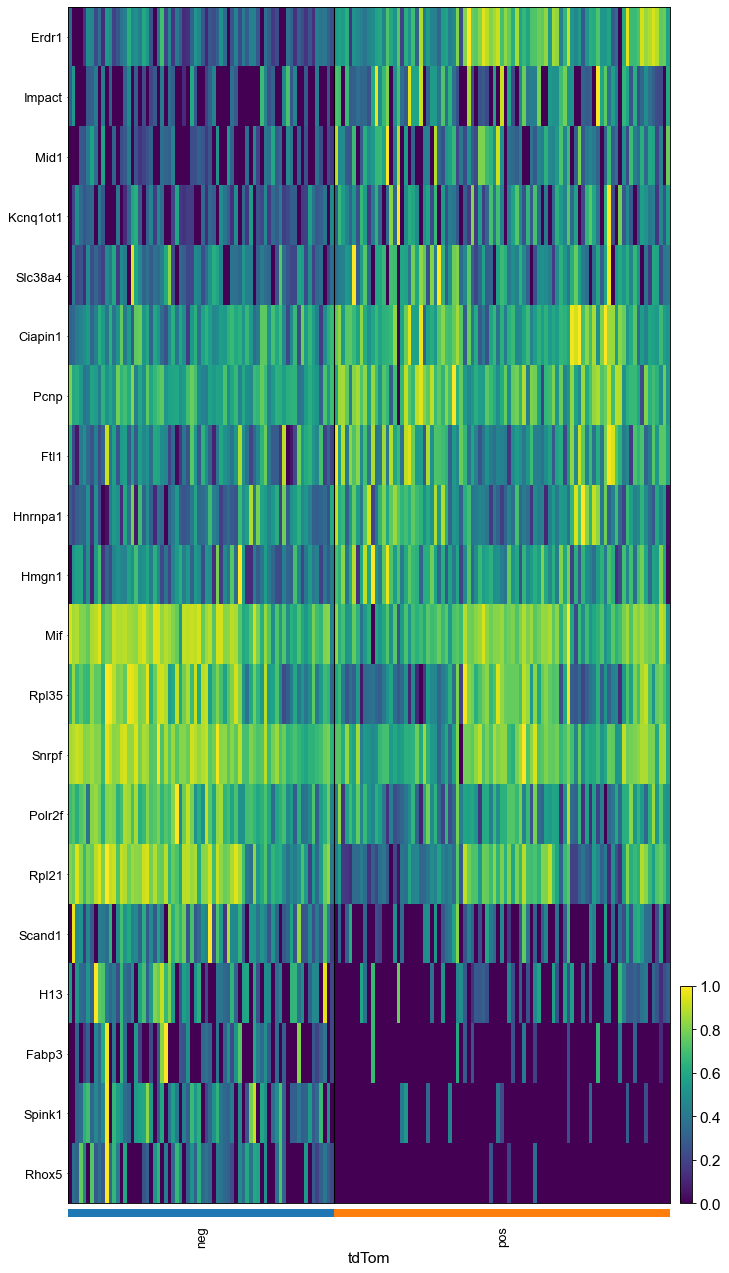

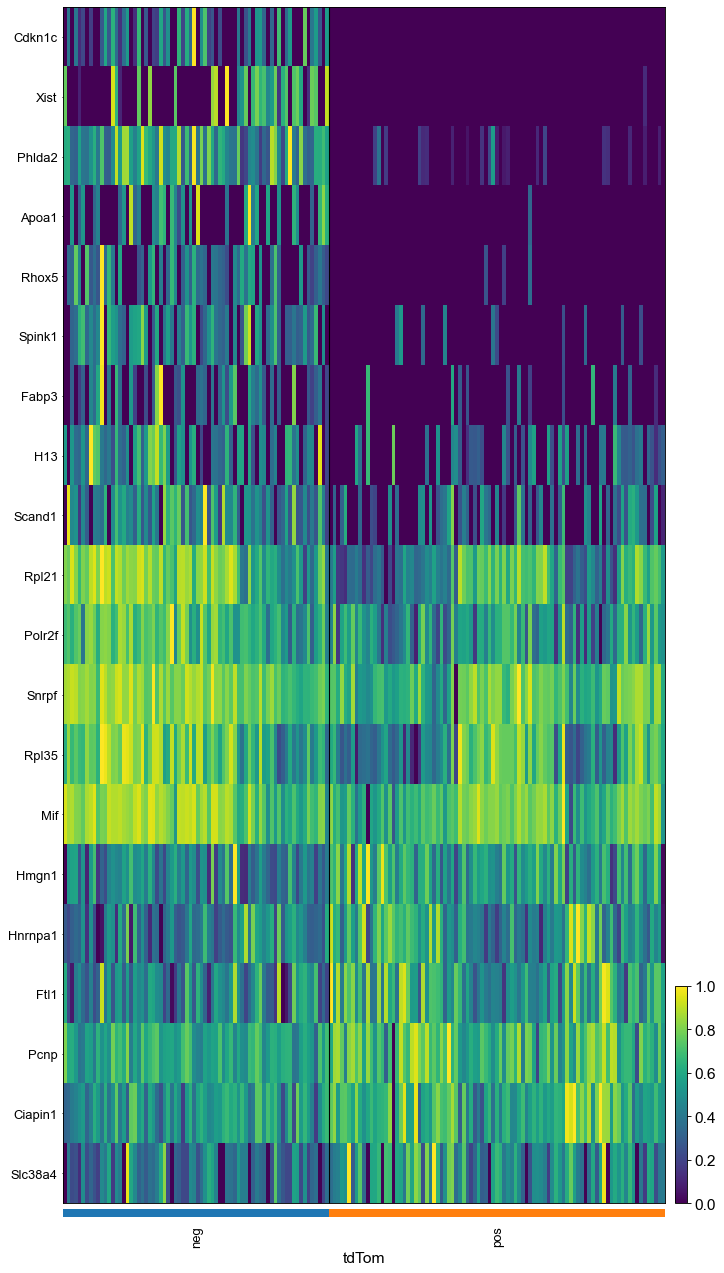

ranking genes
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


Haem3


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-207-83c826f94100>:17: RuntimeWarning: divide by zero encountered in log2
  vec_up = np.where((df3['pos']>=np.log2(0)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
<ipython-input-207-83c826f94100>:18: RuntimeWarning: divide by zero encountered in log2
  vec_down = np.where((df3['neg']>= np.log2(0)) & (df2['neg']<= 0.1) )[0]


11
11


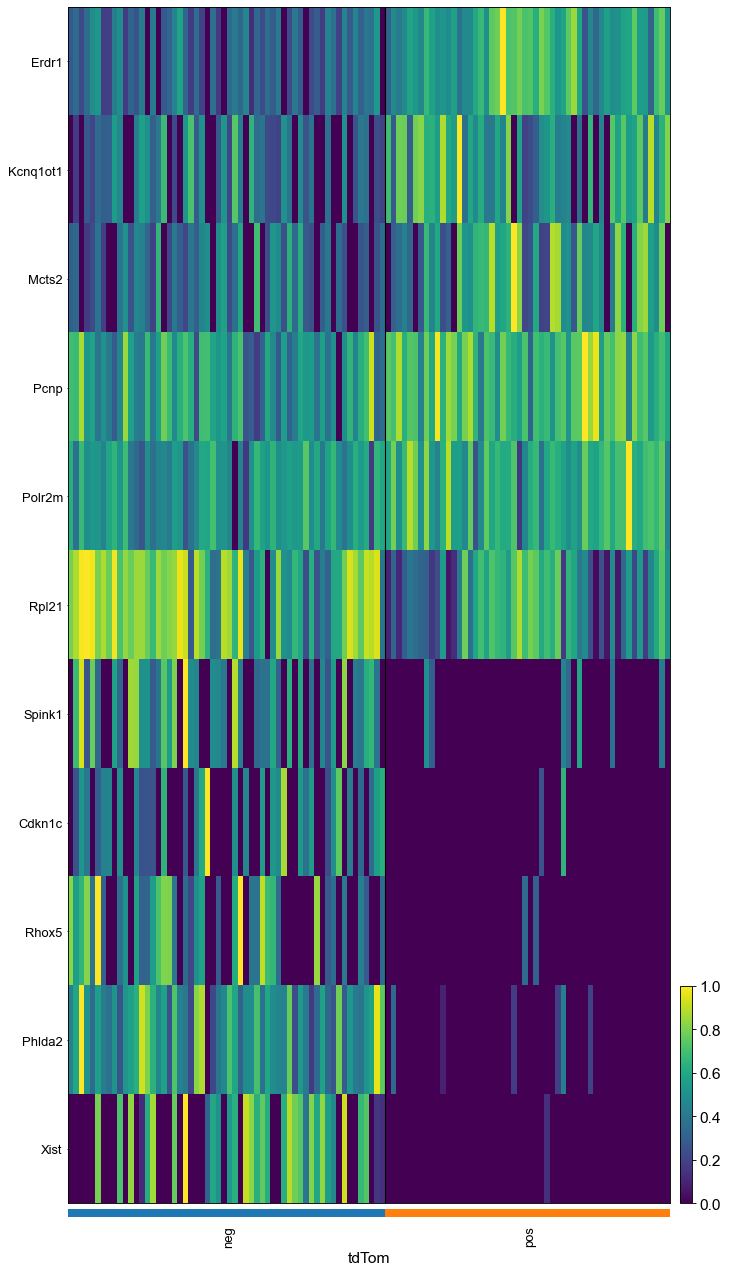

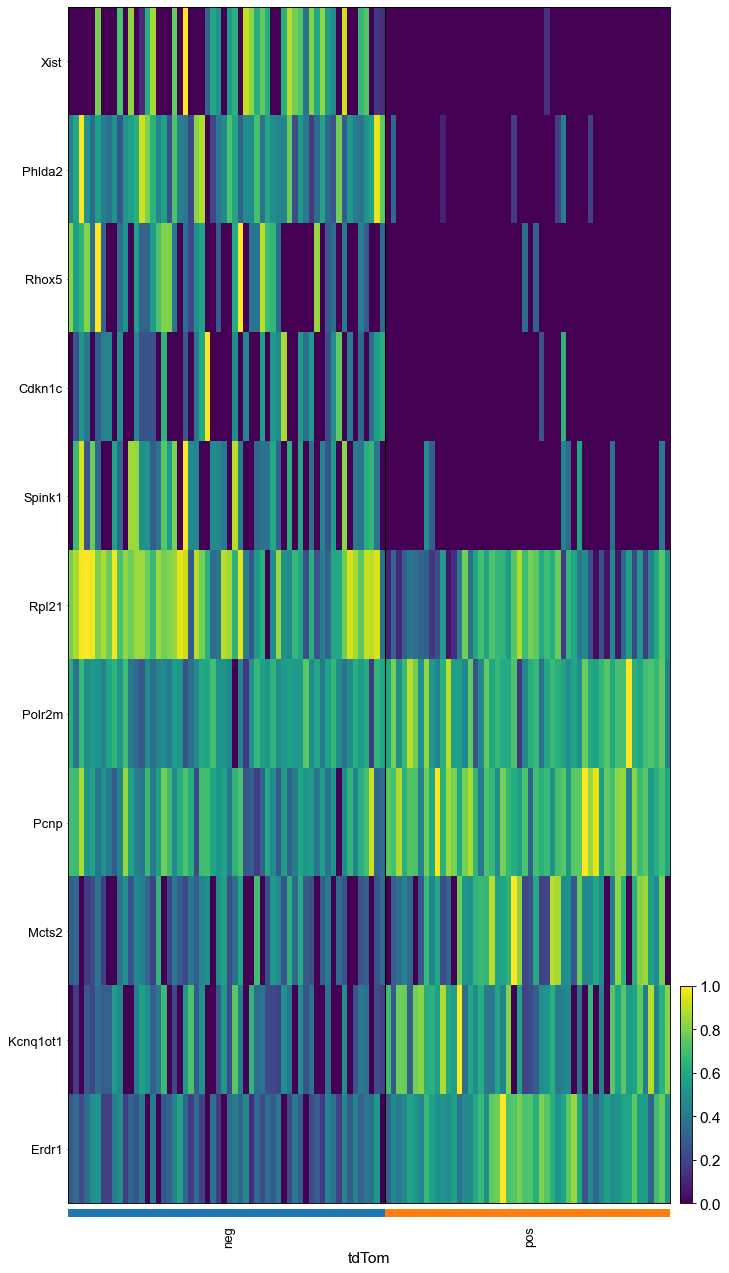

nan


ranking genes
... storing 'barcode' as categorical
... storing 'batch' as categorical
... storing 'celltype' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'colour' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'haem_subclust' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tdTom' as categorical
... storing 'theiler' as categorical
... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by grou

6579
6579


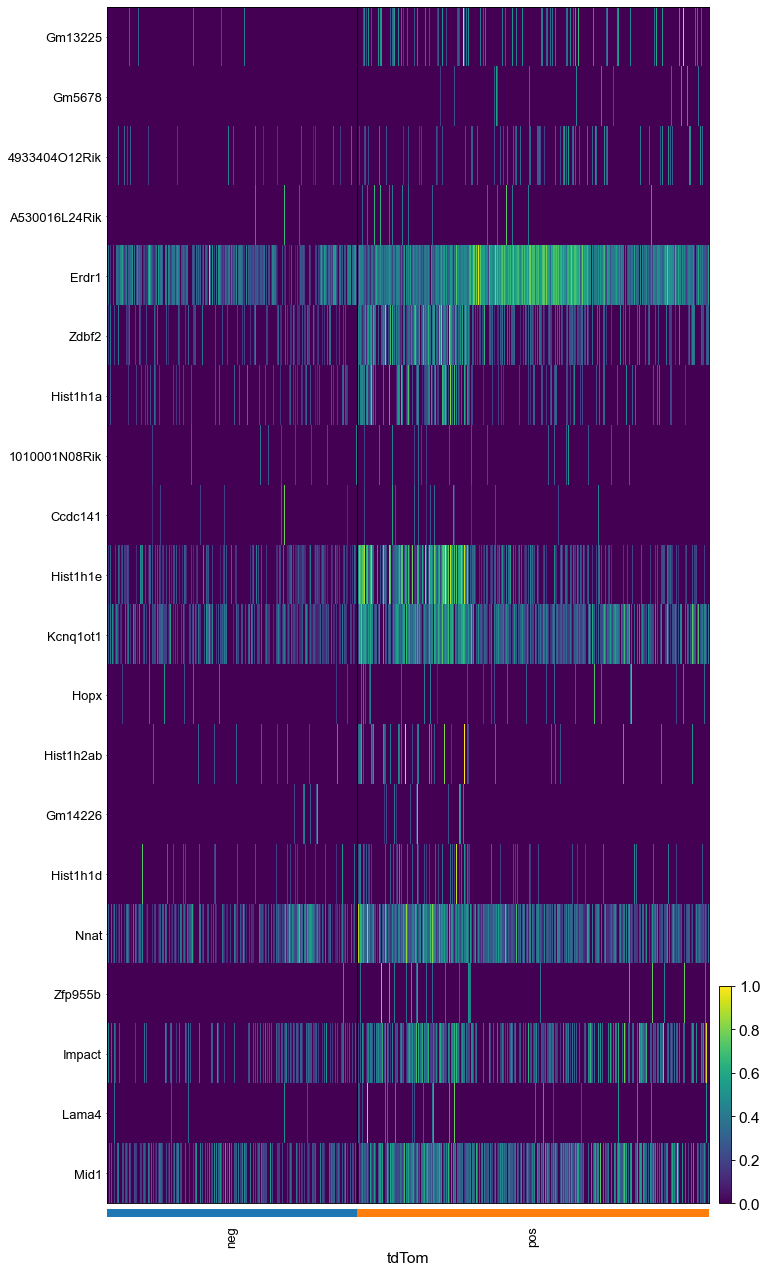

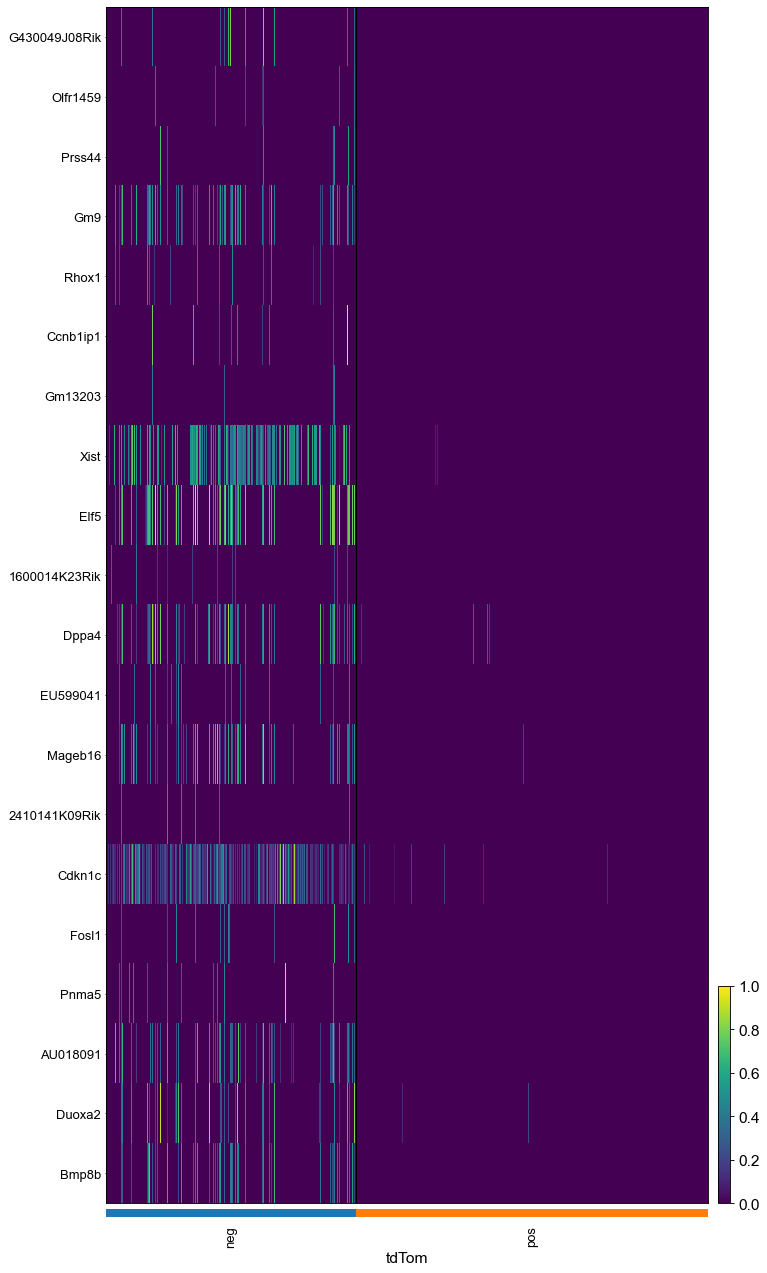

finished ranking genes


6579

In [207]:
## different one to create DF only with gene names
#wt = pd.read_csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/data/wt_tomato_correlations_for_Melania.csv", index_col=1)
sc.settings.figdir = 'C:/Users/aamw4/home/aamw4/plots/heatmaps/'
output_dr = 'C:/Users/aamw4/home/aamw4/plots/MAplots/'
number_genes = []
final = pd.DataFrame()

for pop in list(df_good.index):
    print(pop)
    adata_rid = adata_wt[adata_wt.obs['haem_subclust.mapped'] == pop,:].copy()
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])

    
    vec_up = np.where((df3['pos']>=np.log2(0)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
    vec_down = np.where((df3['neg']>= np.log2(0)) & (df2['neg']<= 0.1) )[0]
    
        
    df_pos = pd.DataFrame(df2.loc[vec_up]['pos'])
    df_pos.index = list(df1.loc[vec_up]['pos'])
    df_pos['lfc'] = list(df3.loc[vec_up]['pos'])
    df_pos = df_pos.sort_values(by='lfc',ascending=False)

 
    df_neg = pd.DataFrame(df2.loc[vec_down]['neg'])
    df_neg.index = list(df1.loc[vec_down]['neg'])
    df_neg['lfc'] = list(df3.loc[vec_down]['neg'])
    df_neg = df_neg.sort_values(by='lfc',ascending=False)

 
    lista_n = df_neg.index
    lista_p = df_pos.index
 
    print(len(lista_p))
    print(len(lista_n))
    
    number_pos = len(lista_p)
    number_neg = len(lista_n)
    
    number_genes.append(number_pos)
    number_genes.append(number_neg)
    
    #make a list with lengths of all lists, sort and take maximum
    
    list_pos = lista_p.tolist() #format to list to add to dataframe
    list_neg = lista_n.tolist()
    
    #create DataFrame final with only gene names according to celltype and tdTom 
    
    df_posi = pd.DataFrame({'pos': list_pos})
    df_nega = pd.DataFrame({'neg': list_neg})
    
    
    columns = create_tuple_for_for_columns(df_posi, pop)
    df_posi.columns = pd.MultiIndex.from_tuples(columns)
    
    index = pd.MultiIndex.from_tuples(df_posi, names=['celltype', 'tdTom'])
    df_posi.columns = index
    
    columns = create_tuple_for_for_columns(df_nega, pop)
    df_nega.columns = pd.MultiIndex.from_tuples(columns)
    
    index = pd.MultiIndex.from_tuples(df_nega, names=['celltype', 'tdTom'])
    df_nega.columns = index 

    df_pn = pd.concat([df_posi, df_nega], axis=1)
    index = pd.MultiIndex.from_tuples(df_pn, names=['celltype', 'tdTom'])
    df_pn.columns = index
    
    final = pd.concat([final, df_pn], axis=1)
    
    adata_rid.var_names_make_unique()
    
    if len(df_posi) > 20:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,0].head(20), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_pos.png' )
    else : 
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,0].head(len(df_posi)), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_pos.png' )
            
    if len(df_nega) > 20:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,1].head(20), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_neg.png' )
    else:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,1].head(len(df_nega)), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_neg.png' )
    
    
print('finished ranking genes')
number_genes.sort(reverse=True)
number_genes[0] #prints highest number of selected genes for any celltype population to adapt range accordingly of df-Dea in initialisation

In [208]:
final.to_csv(output_dr + 'wt_chim_DEGs_final_haem') 

# Gut subcluster

In [209]:
adata_wt.obs['gut_subclust.mapped'] = adata_wt.obs['gut_subclust.mapped'].astype(str)

np.unique(adata_wt.obs['gut_subclust.mapped'])

<ipython-input-209-ea075ec897dd>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_wt.obs['gut_subclust.mapped'] = adata_wt.obs['gut_subclust.mapped'].astype(str)


array(['Foregut 1', 'Foregut 2', 'Hindgut 1', 'Hindgut 2', 'Midgut',
       'Midgut/Hindgut', 'Pharyngeal endoderm', 'nan'], dtype=object)

In [211]:
#only one population passes threshold
df = pd.crosstab(adata_wt.obs['gut_subclust.mapped'], adata_wt.obs['tdTom'])
vec = np.array((df.neg>=0) & (df.pos>=0))
print(vec)
df_good = df.loc[vec] #df.iloc[vec] does not work for one reason I don't understand, but df.loc[voc] takes away index
print(df_good)
print(df_good.dtypes)

[ True  True  True  True  True  True  True  True]
tdTom                 neg   pos
gut_subclust.mapped            
Foregut 1               5     4
Foregut 2               6    10
Hindgut 1               2     1
Hindgut 2              14    24
Midgut                  7     8
Midgut/Hindgut         24    26
Pharyngeal endoderm    40    44
nan                  5505  7761
tdTom
neg    int64
pos    int64
dtype: object


In [ ]:
## different one to create DF only with gene names
wt = pd.read_csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/data/wt_tomato_correlations_for_Melania.csv", index_col=1)
list_names = [name for name in list(wt.index[0:100]) if name in adata.var_names]
sc.settings.figdir = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/heatmaps/'
output_dr = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/MAplots/'
number_genes = []
final = pd.DataFrame()

for pop in list(df_good.index):
    print(pop)
    adata_rid = adata[adata.obs['gut_subclust.mapped'] == pop,:].copy()
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])

    
    vec_up = np.where((df3['pos']>=np.log2(0)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
    vec_down = np.where((df3['neg']>= np.log2(0)) & (df2['neg']<= 0.1) )[0]
    
        
    df_pos = pd.DataFrame(df2.loc[vec_up]['pos'])
    df_pos.index = list(df1.loc[vec_up]['pos'])
    df_pos['lfc'] = list(df3.loc[vec_up]['pos'])
    df_pos = df_pos.sort_values(by='lfc',ascending=False)

 
    df_neg = pd.DataFrame(df2.loc[vec_down]['neg'])
    df_neg.index = list(df1.loc[vec_down]['neg'])
    df_neg['lfc'] = list(df3.loc[vec_down]['neg'])
    df_neg = df_neg.sort_values(by='lfc',ascending=False)

 
    lista_n = df_neg.index
    lista_p = df_pos.index
 
    print(len(lista_p))
    print(len(lista_n))
    
    number_pos = len(lista_p)
    number_neg = len(lista_n)
    
    number_genes.append(number_pos)
    number_genes.append(number_neg)
    
    #make a list with lengths of all lists, sort and take maximum
    
    list_pos = lista_p.tolist() #format to list to add to dataframe
    list_neg = lista_n.tolist()
    
    #create DataFrame final with only gene names according to celltype and tdTom 
    
    df_posi = pd.DataFrame({'pos': list_pos})
    df_nega = pd.DataFrame({'neg': list_neg})
    
    
    columns = create_tuple_for_for_columns(df_posi, pop)
    df_posi.columns = pd.MultiIndex.from_tuples(columns)
    
    index = pd.MultiIndex.from_tuples(df_posi, names=['celltype', 'tdTom'])
    df_posi.columns = index
    
    columns = create_tuple_for_for_columns(df_nega, pop)
    df_nega.columns = pd.MultiIndex.from_tuples(columns)
    
    index = pd.MultiIndex.from_tuples(df_nega, names=['celltype', 'tdTom'])
    df_nega.columns = index 

    df_pn = pd.concat([df_posi, df_nega], axis=1)
    index = pd.MultiIndex.from_tuples(df_pn, names=['celltype', 'tdTom'])
    df_pn.columns = index
    
    final = pd.concat([final, df_pn], axis=1)
    
    adata_rid.var_names_make_unique()
    
    if len(df_posi) > 20:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,0].head(20), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_pos.png' )
    else : 
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,0].head(len(df_posi)), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_pos.png' )
            
    if len(df_nega) > 20:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,1].head(20), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_neg.png' )
    else:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,1].head(len(df_nega)), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_neg.png' )
    
    
print('finished ranking genes')
number_genes.sort(reverse=True)
number_genes[0] #prints highest number of selected genes for any celltype population to adapt range accordingly of df-Dea in initialisation

In [ ]:
final.to_csv(out_folder + 'chim_DEGs_final_gut')

# trying to calculate number of genes appearing in several celltype populations

In [227]:
df_dea = pd.read_csv('C:/Users/aamw4/home/aamw4/wt_chim_DEGs_df_dea')
df_dea
positive_genes = df_dea.iloc[:, 1::6] #selects every column in 6, here corresponding to pop+pos+gene
positive_genes.dropna()
positive_genes
negative_genes = df_dea.iloc[:, 4::6] #same but for negative genes
negative_genes

,Blood progenitors 1_neg_g,Blood progenitors 2_neg_g,Caudal Mesoderm_neg_g,Erythroid1_neg_g,Erythroid2_neg_g,Erythroid3_neg_g,ExE mesoderm_neg_g,Forebrain/Midbrain/Hindbrain_neg_g,Gut_neg_g,Haematoendothelial progenitors_neg_g,Intermediate mesoderm_neg_g,Mesenchyme_neg_g,NMP_neg_g,Nascent mesoderm_neg_g,Paraxial mesoderm_neg_g,Pharyngeal mesoderm_neg_g,Rostral neurectoderm_neg_g,Somitic mesoderm_neg_g,Spinal cord_neg_g,Surface ectoderm_neg_g
0,Xist,Dnah2,Xist,Xist,Cdkn1c,Xist,Xist,Xist,Dnah2,Xist,Cdkn1c,Slc22a18,Dnah2,Xist,Xist,Cdkn1c,Xist,Xist,Xist,Xist
1,Cdkn1c,Xist,Cdkn1c,Spink1,Xist,Cdkn1c,Cdkn1c,Cdkn1c,Cdkn1c,Dnah2,Xist,Cdkn1c,Xist,Cdkn1c,Cdkn1c,Phlda2,Cdkn1c,Cdkn1c,Cdkn1c,Cdkn1c
2,Phlda2,Cdkn1c,Rhox5,Ttr,Ttr,Apoa1,Phlda2,Dnah2,Phlda2,Cdkn1c,Phlda2,Xist,Cdkn1c,Phlda2,Phlda2,Xist,Rhox5,Phlda2,Ttr,Dnah2
3,Ttr,Ttr,Phlda2,Phlda2,Apoa1,Ttr,Slc22a18,Rhox5,Xist,Phlda2,Dnah2,Phlda2,Phlda2,Ttr,Dnah2,Dnah2,Phlda2,Ttr,Phlda2,Phlda2
4,Rhox5,Phlda2,Spink1,Slc32a1,Phlda2,Rbp4,Ttr,Ttr,Rhox5,Ttr,Slc22a18,Trap1a,Ttr,Spink1,Ttr,Ttr,Dnah2,Spink1,Rhox5,Rhox5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
523,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [228]:
columns_pos = positive_genes.columns
columns_pos = columns_pos.tolist()
columns_neg = negative_genes.columns
columns_neg = columns_neg.tolist()
columns_neg

['Blood progenitors 1_neg_g',
 'Blood progenitors 2_neg_g',
 'Caudal Mesoderm_neg_g',
 'Erythroid1_neg_g',
 'Erythroid2_neg_g',
 'Erythroid3_neg_g',
 'ExE mesoderm_neg_g',
 'Forebrain/Midbrain/Hindbrain_neg_g',
 'Gut_neg_g',
 'Haematoendothelial progenitors_neg_g',
 'Intermediate mesoderm_neg_g',
 'Mesenchyme_neg_g',
 'NMP_neg_g',
 'Nascent mesoderm_neg_g',
 'Paraxial mesoderm_neg_g',
 'Pharyngeal mesoderm_neg_g',
 'Rostral neurectoderm_neg_g',
 'Somitic mesoderm_neg_g',
 'Spinal cord_neg_g',
 'Surface ectoderm_neg_g']

In [ ]:
unique_genes_pos = pd.unique(positive_genes[['Allantois_pos_g', 'Blood progenitors 1_pos_g', 'Blood progenitors 2_pos_g',
 'Cardiomyocytes_pos_g', 'Caudal Mesoderm_pos_g', 'Def. endoderm_pos_g', 'Erythroid1_pos_g', 'Erythroid2_pos_g',
 'Erythroid3_pos_g',
 'ExE mesoderm_pos_g',
 'Forebrain/Midbrain/Hindbrain_pos_g',
 'Gut_pos_g',
 'Intermediate mesoderm_pos_g',
 'Mesenchyme_pos_g',
 'NMP_pos_g',
 'Neural crest_pos_g',
 'Paraxial mesoderm_pos_g',
 'Pharyngeal mesoderm_pos_g',
 'Somitic mesoderm_pos_g',
 'Spinal cord_pos_g',
 'Surface ectoderm_pos_g']].values.ravel('K')) #list of unique genes across positive_genes dataframe
len(unique_genes_pos)
unique_genes_neg = pd.unique(negative_genes[['Allantois_neg_g',
 'Blood progenitors 1_neg_g',
 'Blood progenitors 2_neg_g',
 'Cardiomyocytes_neg_g',
 'Caudal Mesoderm_neg_g',
 'Def. endoderm_neg_g',
 'Erythroid1_neg_g',
 'Erythroid2_neg_g',
 'Erythroid3_neg_g',
 'ExE mesoderm_neg_g',
 'Forebrain/Midbrain/Hindbrain_neg_g',
 'Gut_neg_g',
 'Intermediate mesoderm_neg_g',
 'Mesenchyme_neg_g',
 'NMP_neg_g',
 'Neural crest_neg_g',
 'Paraxial mesoderm_neg_g',
 'Pharyngeal mesoderm_neg_g',
 'Somitic mesoderm_neg_g',
 'Spinal cord_neg_g',
 'Surface ectoderm_neg_g']].values.ravel('K')) #list of unique genes across positive_genes dataframe

In [ ]:
positive_genes.columns
negative_genes

In [ ]:
#trying to sum occurences of genes in positive_genes

##for every unique gene, for every column go over its contents, add n=+1 every time it encounters it
d=0
lista=[]
columns=list(positive_genes)
for gene in unique_genes_pos: 
    for i in range(len(positive_genes.columns)):
        for j in range(len(positive_genes[positive_genes.columns[i]])):
            if positive_genes.iloc[j,i]==gene:
                d+=1
    lista.append(d)
    d=0
    
print(lista)
len(lista)



In [ ]:
d=0
listb=[]
columns=list(negative_genes)
for gene in unique_genes_neg: 
    for i in range(len(negative_genes.columns)):
        for j in range(len(negative_genes[negative_genes.columns[i]])):
            if negative_genes.iloc[j,i]==gene:
                d+=1
    listb.append(d)
    d=0
    
print(listb)
len(listb)


In [ ]:
#merged_pos = pd.DataFrame(np.column_stack([unique_genes_pos, lista]), 
                             #columns=['genes', 'counts'])
merged_pos = pd.DataFrame({'genes' : unique_genes_pos, 'counts': lista})



merged_pos.set_index('genes', inplace=True)
merged_pos.counts = pd.to_numeric(merged_pos.counts, errors='coerce')
merged_pos.sort_values(by=['counts'], inplace=True, ascending=False)
merged_pos[:30]

In [ ]:
merged_neg = pd.DataFrame(np.column_stack([unique_genes_neg, listb]), 
                               columns=['genes', 'counts'])

merged_neg.set_index('genes', inplace=True)
merged_neg.counts = pd.to_numeric(merged_neg.counts, errors='coerce')
merged_neg.sort_values(by=['counts'], inplace=True, ascending=False)
merged_neg[:30]

# Other method to do the same

In [229]:
count = pd.Series(positive_genes.squeeze().values.ravel()).value_counts()
counts = pd.DataFrame({'Gene': count.index, 'Count':count.values})
counts[:30]
counts
positivegenes = list(counts['Gene'][:30])

In [230]:
counts[:50]

,Gene,Count
0,Mid1,20
1,Kcnq1ot1,20
2,Erdr1,20
3,Impact,18
4,Mcts2,18
5,Hist1h1e,14
6,Slc38a4,14
7,4933404O12Rik,14
8,Nnat,13
9,Zdbf2,13


In [231]:
len(positivegenes)

30

In [233]:
counts.to_csv('C:/Users/aamw4/home/aamw4/wt_repeated_DEG_positive.csv')

In [234]:
count = pd.Series(negative_genes.squeeze().values.ravel()).value_counts()
counts = pd.DataFrame({'Gene': count.index, 'Count':count.values})
counts[:30]
negativegenes = list(counts['Gene'][:30])

In [235]:
counts.to_csv('C:/Users/aamw4/home/aamw4/wt_repeated_DEG_negative.csv')

# Venn diagrams

In [ ]:
for pop in list_common:
    set1 = set([gene for gene in list(df_chim[pop + '_pos_g'])])
    set2 = set([gene for gene in list(df_wt[pop + '_pos_g'])])
    set3 = set(positivegenes)

    venn3([set1, set2, set3], ('Chimera', 'WT', 'Repeated_genes'))

    plt.show()
    plt.title(pop, fontsize = 20)
    #plt.savefig(out_folder + '{}'.format(pop)+'_VENN_KO.png')

In [ ]:
#absolutely unique genes
ran = range(0,50)
abs_unique_genes = pd.DataFrame(ran)
for pop in list_common:    
    dfn = [gene for gene in list(df_chim[pop + '_neg_g']) if gene not in list(df_wt[pop + '_neg_g']) and gene not in list(negativegenes)]
    dfp = [gene for gene in list(df_chim[pop + '_pos_g']) if gene not in list(df_wt[pop + '_pos_g']) and gene not in list(positivegenes)]
    abs_unique_genes[pop + '_neg_g'] = pd.Series(dfn)
    abs_unique_genes[pop + '_pos_g'] = pd.Series(dfp)
abs_unique_genes

In [ ]:
abs_unique_genes.to_csv(out_folder + 'absolutely_unique_DEGs')

# gene set enrichment analysis

In [212]:
cl1 = adata_wt[adata_wt.obs['celltype.mapped'] == 'Surface ectoderm',:]
cl1.obs['tdTom'].value_counts()

pos    457
neg    257
Name: tdTom, dtype: int64

In [219]:
#Available databases : ‘Human’, ‘Mouse’, ‘Yeast’, ‘Fly’, ‘Fish’, ‘Worm’ 
gene_set_names = gseapy.get_library_name()
print(gene_set_names)

['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CORUM', 'COVID-19_Related_Gene_Sets', 'Cancer_Cell_Line_Encyclopedia', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_WG_CRISPR_Screens_Broad_CellLines_2019', 'DepMap_WG_CRISPR_Screens_Sanger_CellLines_2019', 'DisGeNET', 'Disease_Perturbations_from_GEO_down', 'Disease_Perturbations_from_GEO_up', 'Disease_Signatures_from_GEO_down_2014', 'Disease_Signatures_from_GEO_up_2014', 'DrugMatrix', 'Drug_Perturbations_from_GEO_2014', 'Drug_Perturbations_

In [220]:
sc.tl.rank_genes_groups(cl1, groupby="tdTom", method='wilcoxon')
glist = sc.get.rank_genes_groups_df(cl1, group='pos')['names'].squeeze().str.strip().tolist()
print(len(glist))

ranking genes
C:\Users\aamw4\Anaconda3\lib\site-packages\anndata\_core\anndata.py:1207: ImplicitModificationWarning: Initializing view as actual.
  warnings.warn(
Trying to set attribute `.obs` of view, copying.
... storing 'batch' as categorical
Trying to set attribute `.obs` of view, copying.
... storing 'celltype' as categorical
Trying to set attribute `.obs` of view, copying.
... storing 'celltype.mapped' as categorical
Trying to set attribute `.obs` of view, copying.
... storing 'closest.cell' as categorical
Trying to set attribute `.obs` of view, copying.
... storing 'colour' as categorical
Trying to set attribute `.obs` of view, copying.
... storing 'endo_gutCluster' as categorical
Trying to set attribute `.obs` of view, copying.
... storing 'endo_trajectoryName' as categorical
Trying to set attribute `.obs` of view, copying.
... storing 'haem_subclust' as categorical
Trying to set attribute `.obs` of view, copying.
... storing 'sample' as categorical
Trying to set attribute `.o

27151


In [221]:
#convert to uppercase, necessary for next function
converted_list = [x.upper() for x in glist]
print(converted_list)

['ERDR1', 'MID1', 'MT-CO1', 'KCNQ1OT1', 'PCNP', 'MCTS2', 'CIAPIN1', 'IMPACT', 'ZDBF2', 'HMGN1', 'HIST1H1E', 'CSNK1A1', 'MT-ATP6', 'PRRC2C', 'NEDD4', 'MT-ND4', 'NNAT', 'HIST1H1B', 'SMARCA5', 'TOMM20', 'SMARCC1', 'EPRS', 'MT-CO3', 'DDX3Y', 'SRSF3', 'RBM3', 'RIF1', 'CUL1', 'PAPOLA', 'USP34', '4933404O12RIK', 'DNMT1', 'HNRNPDL', 'SYNCRIP', 'SRSF7', 'PCM1', 'THRAP3', 'NAP1L1', 'HSPA4', 'CCNG1', 'WHSC1', 'MT-CYTB', 'PPHLN1', 'CDK5RAP1', 'IGF2BP1', 'FUBP1', 'DHX9', 'GM13225', 'SFPQ', 'BAZ1B', 'CHD1', 'TNKS2', 'PRTG', 'SCAF11', 'EIF3A', 'SENP1', 'APOPT1', 'ANP32E', 'DDX5', 'CKAP5', 'CACYBP', 'UBXN1', '1110004E09RIK', 'MRPL32', 'PAFAH1B1', 'CLSPN', 'HNRNPUL2', 'NR6A1', 'EML4', 'NHP2L1', 'PLEKHF2', 'KIF20B', 'PHF3', 'IWS1', 'YAM1', 'SLC38A4', 'C1D', 'ATAD2', 'GPBP1', 'ZFP638', 'HSPD1', 'XPO1', 'SRSF2', 'FNDC3A', 'GON4L', 'EIF5', 'DTYMK', 'FBXO5', 'CCT4', 'EIF4G2', 'MARCH5', 'MARK3', 'SEC31A', '2810417H13RIK', 'ZFP106', 'TSR1', 'SMARCAD1', 'TRIM33', 'EEF1G', 'NAA50', 'SRRM2', 'H2AFZ', 'TGS1', 'ZF

In [222]:
import requests 

In [223]:
enr_res = gseapy.enrichr(gene_list=converted_list,
                     gene_sets='GO_Biological_Process_2018')
                    
            

Exception: Error analyzing gene list

In [ ]:
enr = gseapy.enrichr(gene_list=converted_list,
                     organism='Mouse',
                     gene_sets=['GO_Biological_Process_2018'], #GO_Biological_Process_2018
                     description='pathway',
                     cutoff = 0.5)

In [ ]:
enr_res.results.head()

In [ ]:
cl1.raw.X.shape

In [ ]:
# filter for genes that are expressed in more than 5 cells
tmp = cl1.raw.to_adata() 
sc.pp.calculate_qc_metrics(tmp, percent_top=None, log1p=False, inplace=True)
tmp = tmp[:,tmp.var['n_cells_by_counts']>5]